# 02 · Exploratory Data Analysis

Inputs: `Corona_Mifkad2_merged.csv` (daily panel ✕ census) and
`Corona_loc_processed.csv` (daily panel), both from notebook 01.

**Questions this notebook answers, and the statistical tool used for each**

| question | visualization / statistic |
|----------|---------------------------|
| Are COVID waves national or local? | national vs 3-city curves + whole-country weekly heat-map |
| Do neighbourhoods inside one city move together? | within-city median / mean / IQR band over time |
| Does testing behaviour distort the infection rate? | infection rate vs daily-testing-volume bins; testing-intensity distribution |
| Does the recent past predict the near future? | Spearman autocorrelation of `infection_rate(t)` vs `infection_rate(t+lag)` |
| Is a naive "tomorrow = today" forecast already good? | persistence-forecast MAE by horizon — the baseline every model must beat |
| Are socio-demographic associations stable across waves? | per-wave Spearman(feature, infection burden) heat-map |
| Vaccination coverage & data quality | per-city coverage curves + QC (values > 100 %); wave-start coverage vs burden |
| Weekly reporting artefacts | infection rate / testing by day-of-week |

In [1]:
# --- repo bootstrap: make every path in this notebook repo-relative ---
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data" / "raw").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "data" / "raw").exists(), "launch this notebook from inside the repo"
os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /home/bcrlab/igguest/porat_naama


### The EDA story at a glance *(committed figures; the code cells below regenerate them)*

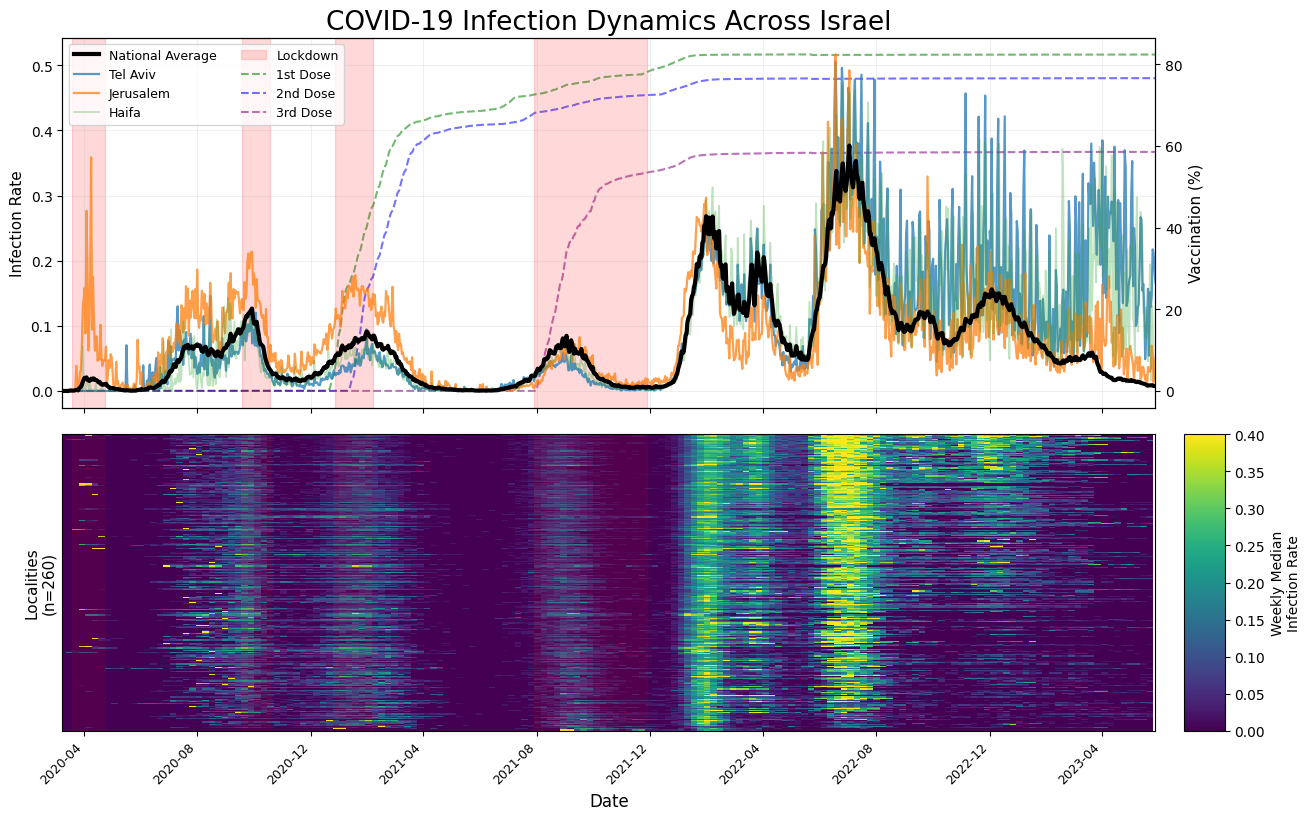

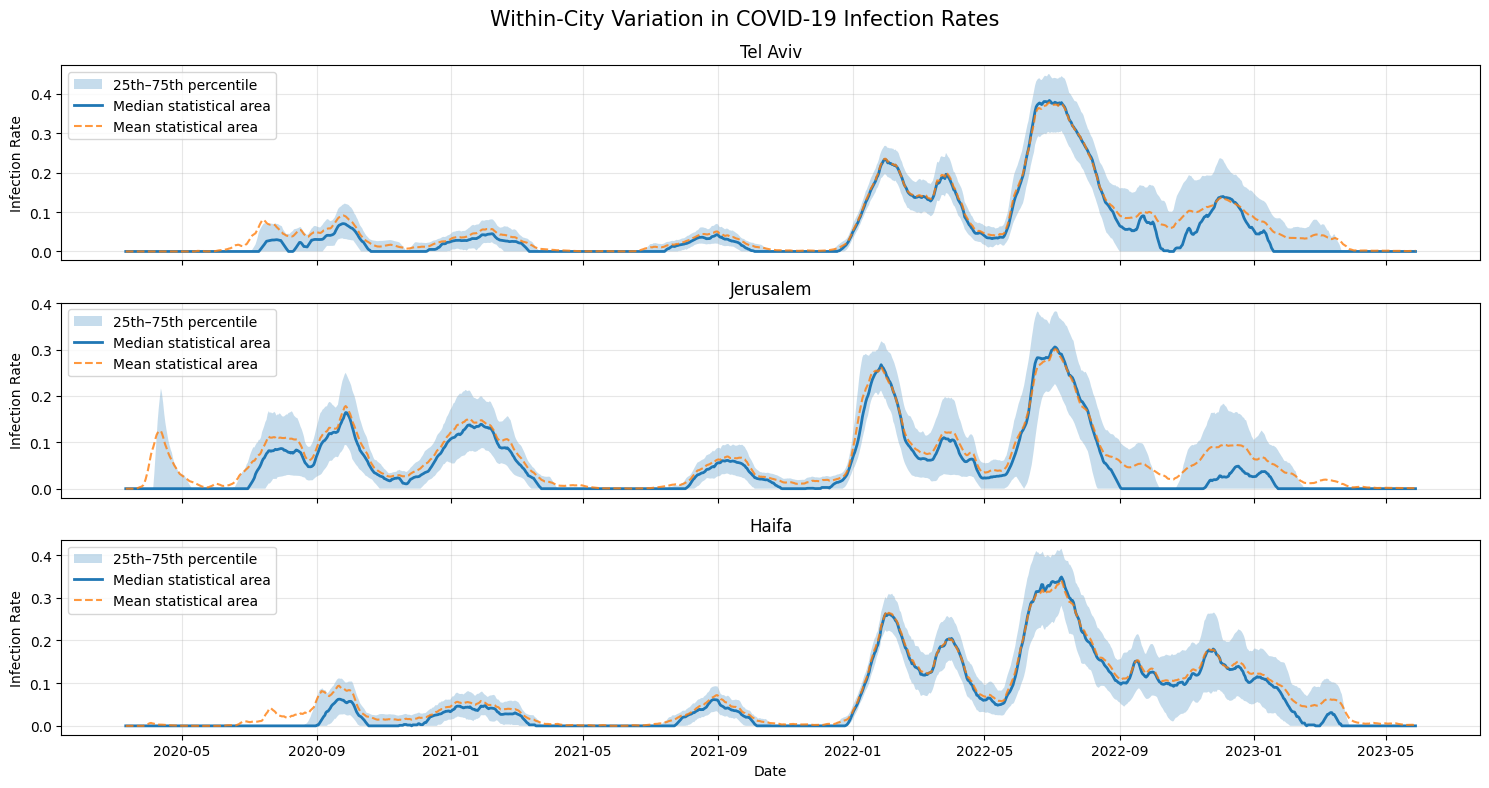

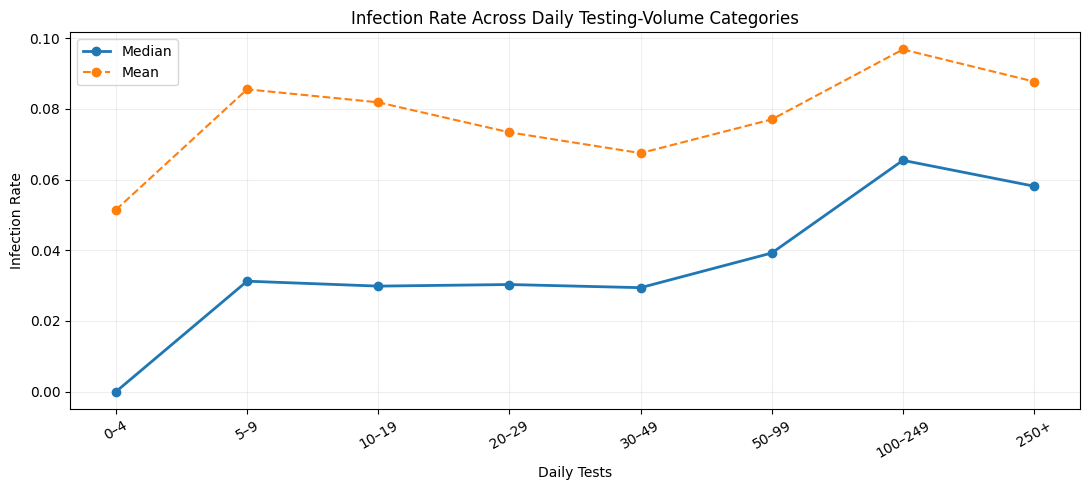

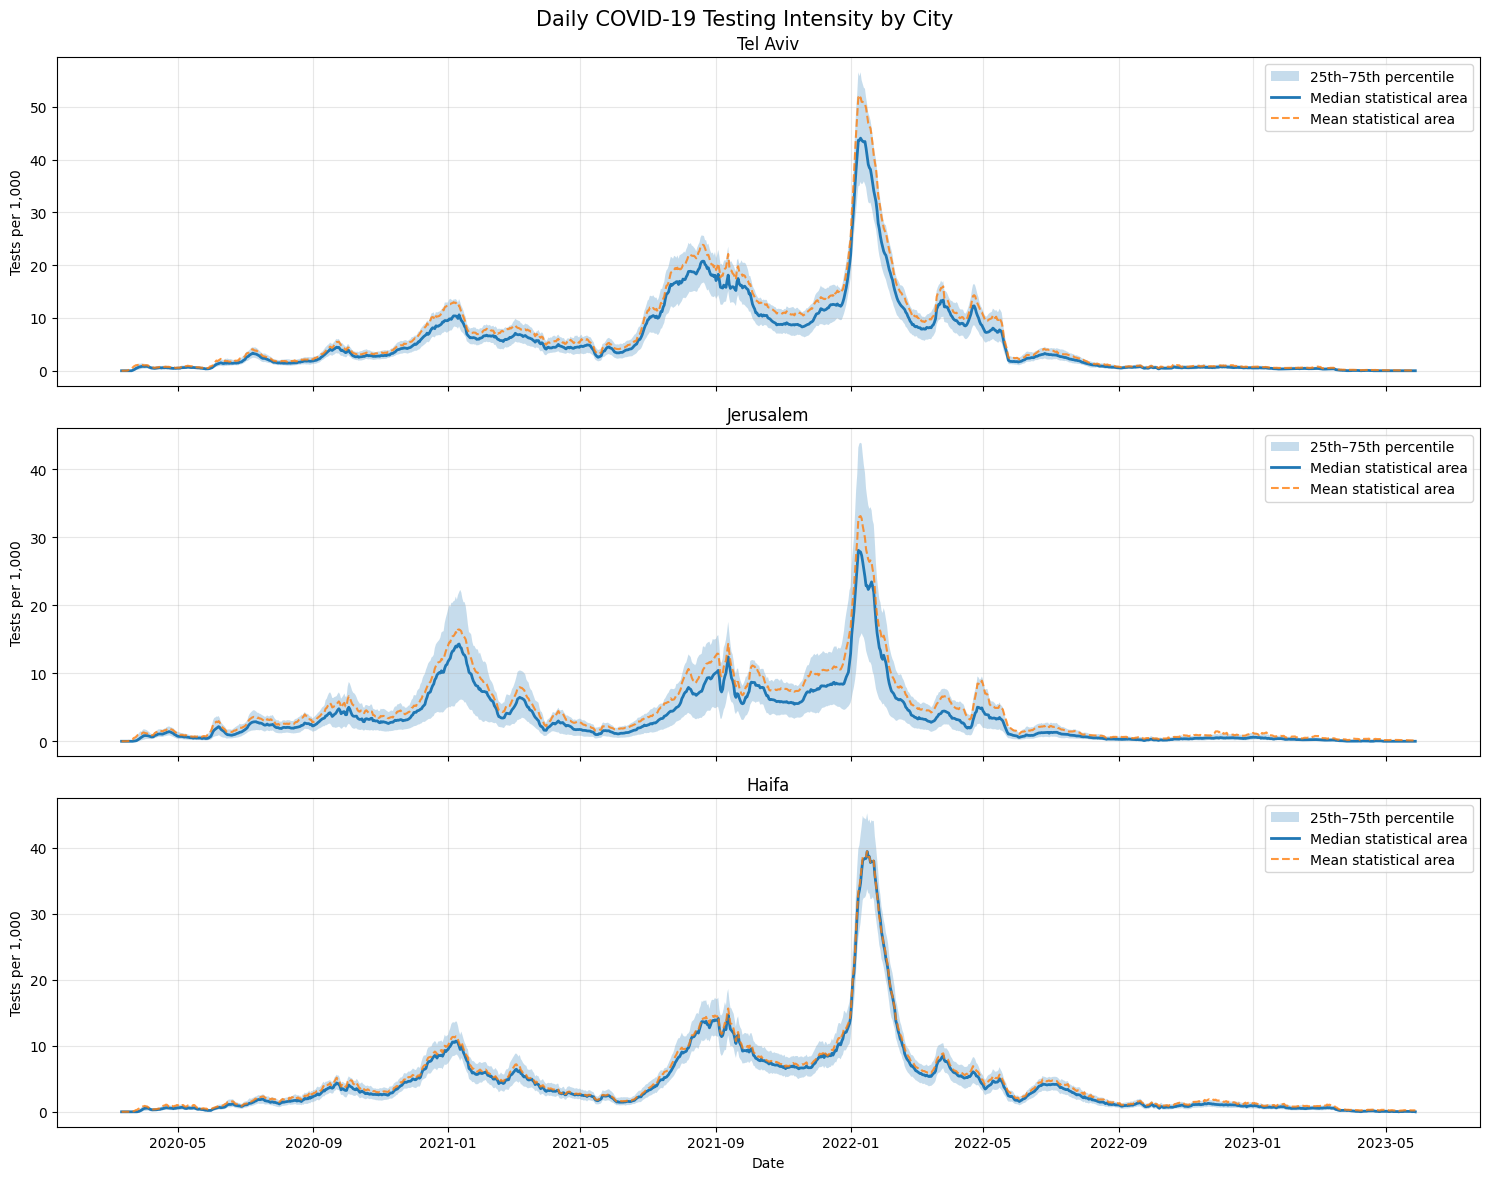

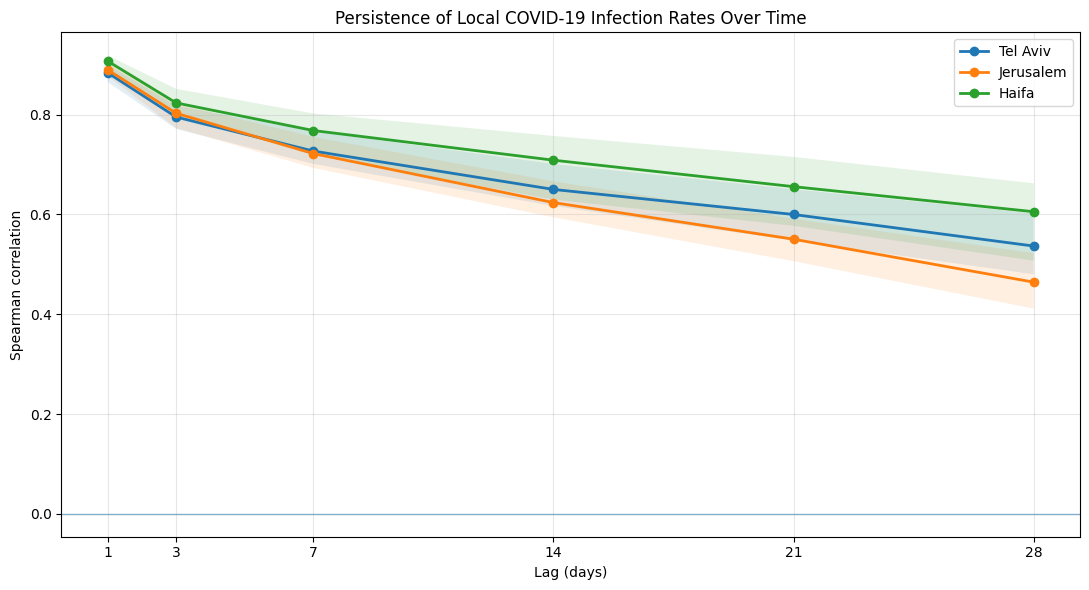

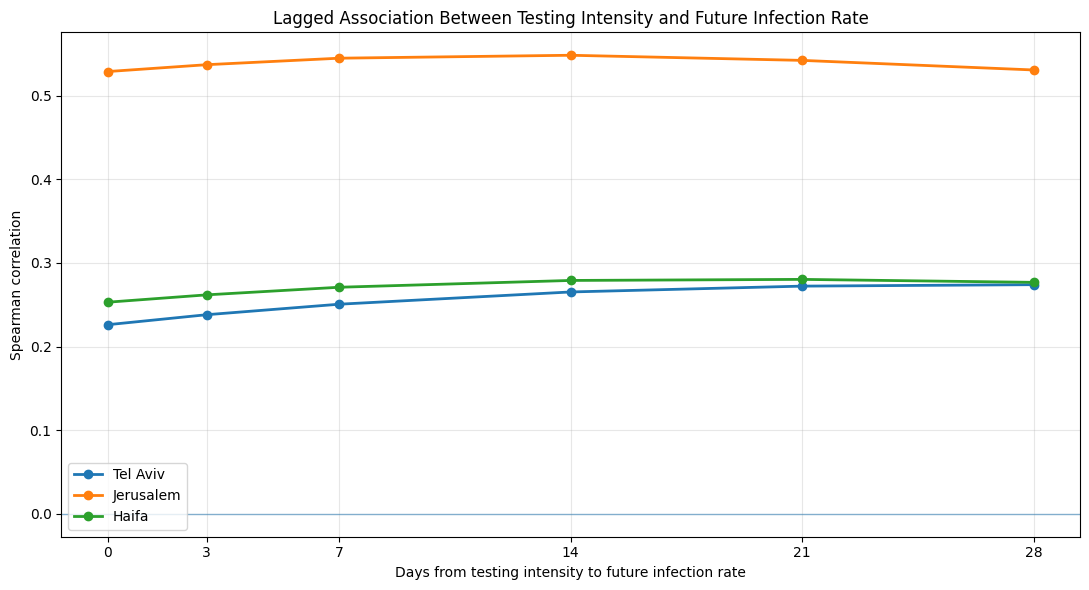

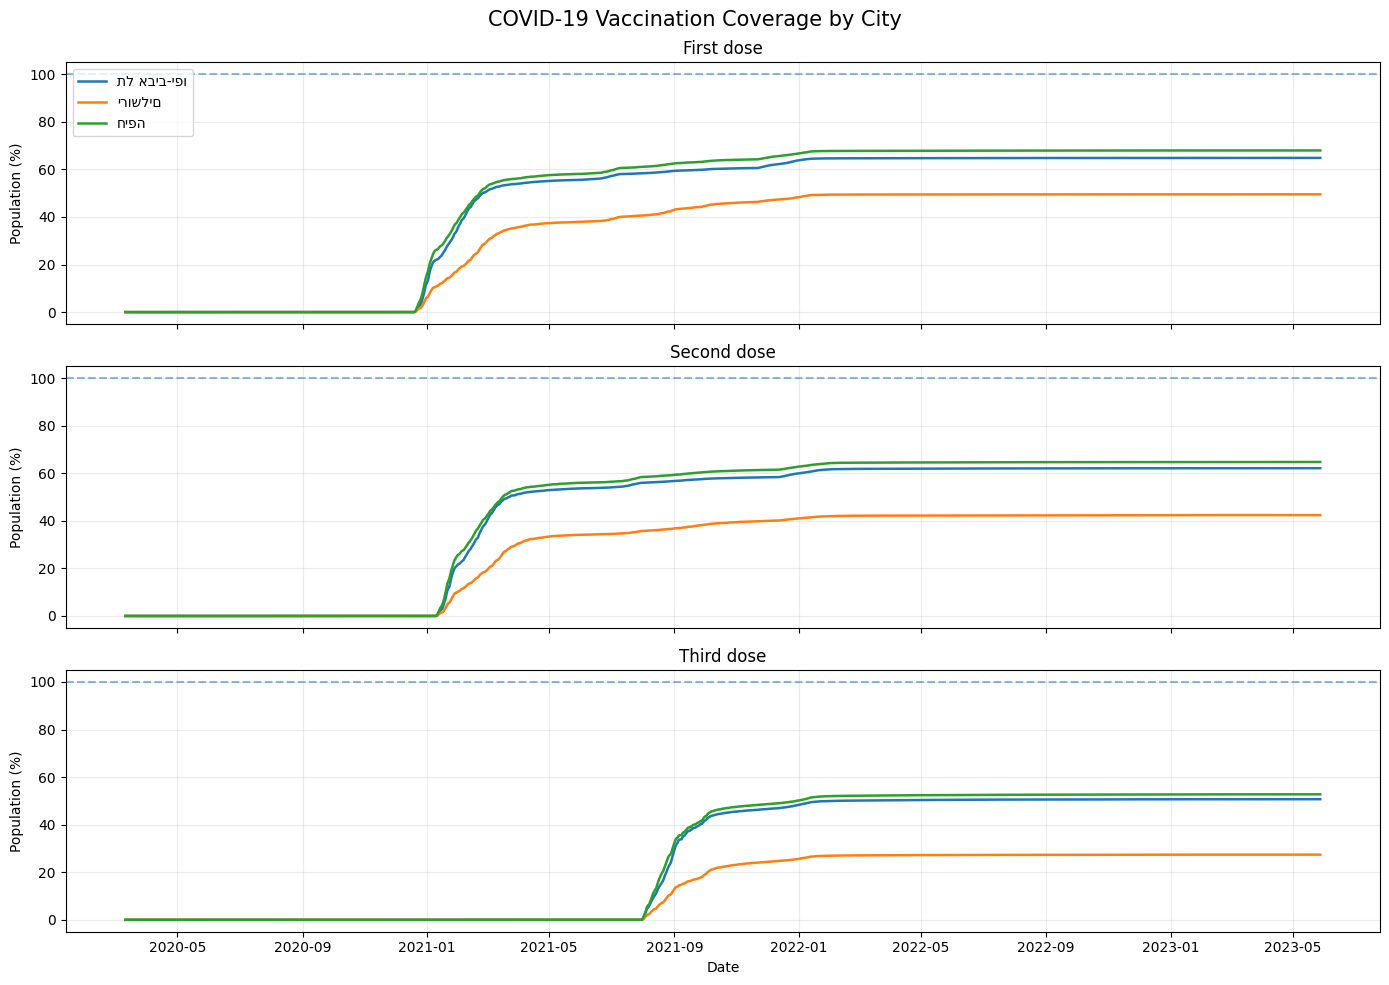

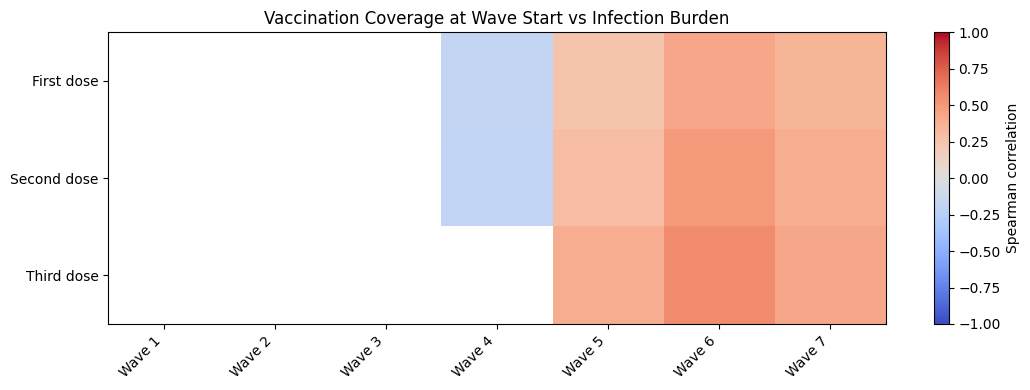

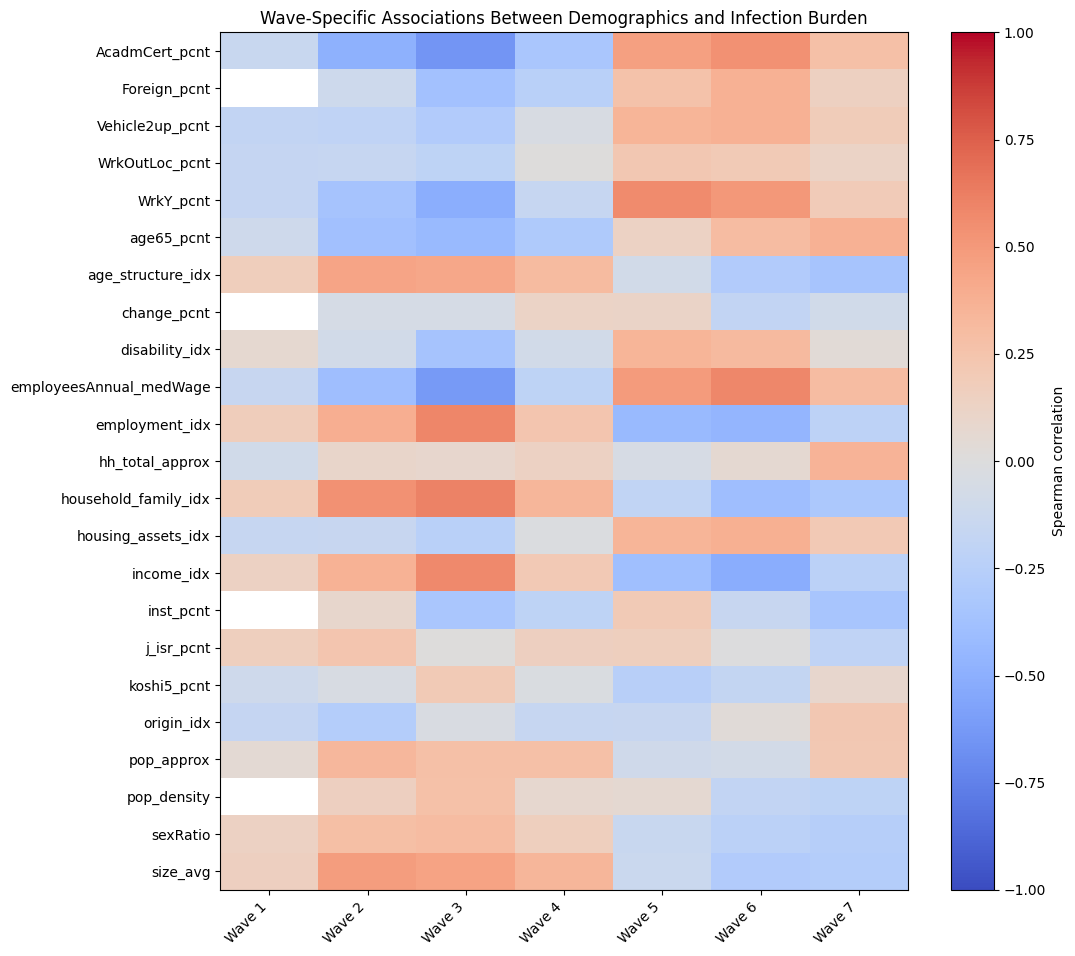

In [2]:
from IPython.display import Image, display
import glob
for f in sorted(glob.glob("final_submission/figures/02_eda/*.png")):
    display(Image(filename=f))

## Load

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

Merged_df_PATH = Path("data/processed/Corona_Mifkad2_merged.csv")
Corona_loc_df_PATH = Path("data/processed/Corona_loc_processed.csv")

OUT_DIR = Path("outputs/EDA")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Running list of (path, description) for every file this notebook saves
output_log = []

def log_output(path, description, description_he):
    output_log.append({"file_path": str(path), "contents": description, "contents_he": description_he})
    print("Saved:", path)

In [4]:
df_merged = pd.read_csv(Merged_df_PATH, dtype={"City_agas_code": str})
df_merged.set_index("City_agas_code", inplace=True)
df_merged.head()

/tmp/ipykernel_1318260/2884815790.py:1: DtypeWarning: Columns (27,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged = pd.read_csv(Merged_df_PATH, dtype={"City_agas_code": str})


,Unnamed: 0,town,date,is_city_aggregate,infection_rate,recovery_ratio,recovery_index,is_lockdown,infection_rate_lag1,infection_rate_lag2,...,household_family_idx,employment_idx,income_idx,housing_assets_idx,disability_idx,has_census,percent_vaccinated_first_dose,percent_vaccinated_second_dose,percent_vaccinated_third_dose,panic_index
City_agas_code,,,,,,,,,,,,,,,,,,,,,
1015_0,0,מבשרת ציון,2020-03-11,1,0.0,0.0,0.0,0,0.0,0.0,...,NaN,-0.761493,NaN,0.860699,1.06418,1,0.0,0.0,0.0,0.0
1015_0,1,מבשרת ציון,2020-03-12,1,0.0,0.0,0.0,0,0.0,0.0,...,NaN,-0.761493,NaN,0.860699,1.06418,1,0.0,0.0,0.0,0.0
1015_0,2,מבשרת ציון,2020-03-13,1,0.0,0.0,0.0,0,0.0,0.0,...,NaN,-0.761493,NaN,0.860699,1.06418,1,0.0,0.0,0.0,0.0
1015_0,3,מבשרת ציון,2020-03-14,1,0.0,0.0,0.0,0,0.0,0.0,...,NaN,-0.761493,NaN,0.860699,1.06418,1,0.0,0.0,0.0,0.0
1015_0,4,מבשרת ציון,2020-03-15,1,0.0,0.0,0.0,0,0.0,0.0,...,NaN,-0.761493,NaN,0.860699,1.06418,1,0.0,0.0,0.0,0.0


In [5]:
df_loc_corona = pd.read_csv(Corona_loc_df_PATH, dtype={"City_agas_code": str})
df_loc_corona.set_index("City_agas_code", inplace=True)
df_loc_corona.head()

,Unnamed: 0,town,date,accumulated_vaccination_first_dose,accumulated_vaccination_second_dose,accumulated_vaccination_third_dose,is_city_aggregate,tested_daily,infection_rate,recovery_ratio,...,infection_rate_window_days,is_lockdown,infection_rate_lag1,infection_rate_lag2,infection_rate_lag3,infection_rate_lag7,infection_rate_lag14,infection_rate_roll7,infection_rate_roll14,infection_rate_roll28
City_agas_code,,,,,,,,,,,,,,,,,,,,,
1015_0,0,מבשרת ציון,2020-03-11,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1015_0,1,מבשרת ציון,2020-03-12,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1015_0,2,מבשרת ציון,2020-03-13,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1015_0,3,מבשרת ציון,2020-03-14,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1015_0,4,מבשרת ציון,2020-03-15,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2.1 · National vs. local dynamics
Waves are strongly **synchronised in time** across the country, but their **amplitude differs by locality**, and within a single wave there is large between-area heterogeneity — the whole motivation for modelling at area level.

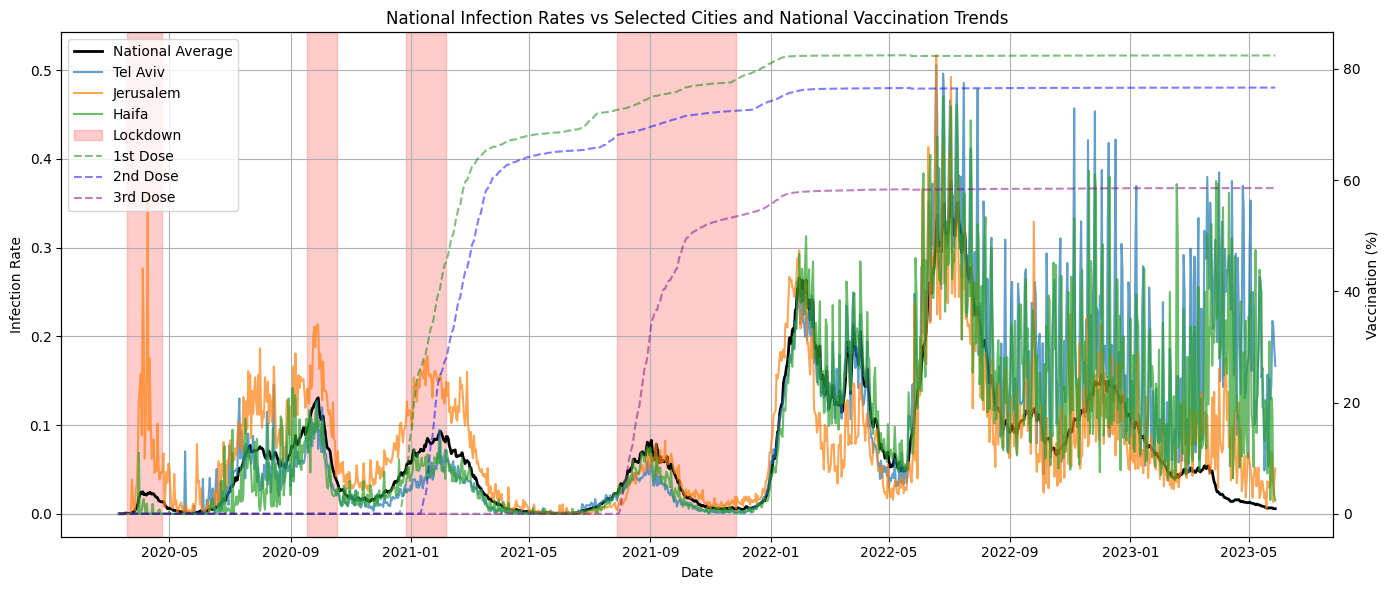

In [6]:
##general grph for infection rate and vaccination trends

# Make sure date is stored as datetime
df_merged['date'] = pd.to_datetime(df_merged['date'])


# National trend
national_trend = df_merged.groupby('date')['infection_rate'].mean()
vac_1_national_trend = df_merged.groupby('date')['percent_vaccinated_first_dose'].mean()
vac_2_national_trend = df_merged.groupby('date')['percent_vaccinated_second_dose'].mean()
vac_3_national_trend = df_merged.groupby('date')['percent_vaccinated_third_dose'].mean()




# Selected cities
selected_cities = ['5000_0', '3000_0', '4000_0']  # Tel Aviv, Jerusalem, Haifa
city_trends = {}

for city in selected_cities:
    city_data = df_merged[df_merged.index == city].copy()
    city_data = city_data.sort_values('date')
    city_trends[city] = city_data.set_index('date')['infection_rate']

# Lockdown periods
lockdown_periods = [('2020-03-19', '2020-04-24'),
                    ('2020-09-18', '2020-10-18'),
                    ('2020-12-27', '2021-02-06'),
                    ('2021-07-29', '2021-11-27')]
lockdown_periods = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in lockdown_periods]

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot national trend
ax1.plot(national_trend.index, national_trend.values, label='National Average', linewidth=2, color='black')

# Plot selected cities
for city, series in city_trends.items():
    label = 'Tel Aviv' if city == '5000_0' else 'Jerusalem' if city == '3000_0' else 'Haifa' if city == '4000_0' else city
    ax1.plot(series.index, series.values, label=label, alpha=0.7)

# Lockdown shading
for start, end in lockdown_periods:
    ax1.axvspan(start, end, color='red', alpha=0.2, label='Lockdown')

# Secondary Y-axis for vaccination trends

ax2 = ax1.twinx()
ax2.plot(vac_1_national_trend.index, vac_1_national_trend.values, label='1st Dose', alpha=0.5, color='green', linestyle='--')
ax2.plot(vac_2_national_trend.index, vac_2_national_trend.values, label='2nd Dose', alpha=0.5, color='blue', linestyle='--')
ax2.plot(vac_3_national_trend.index, vac_3_national_trend.values, label='3rd Dose', alpha=0.5, color='purple', linestyle='--')
ax2.set_ylabel("Vaccination (%)")

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1 + labels2, handles1 + handles2))

ax1.set_title("National Infection Rates vs Selected Cities and National Vaccination Trends")
ax1.set_xlabel("Date")
ax1.set_ylabel("Infection Rate")
ax1.legend(by_label.values(), by_label.keys(), loc='upper left')
ax1.grid(True)
fig.tight_layout()
plt.show()

Localities plotted: 260
Weeks plotted: 168
Color scale maximum: 0.400


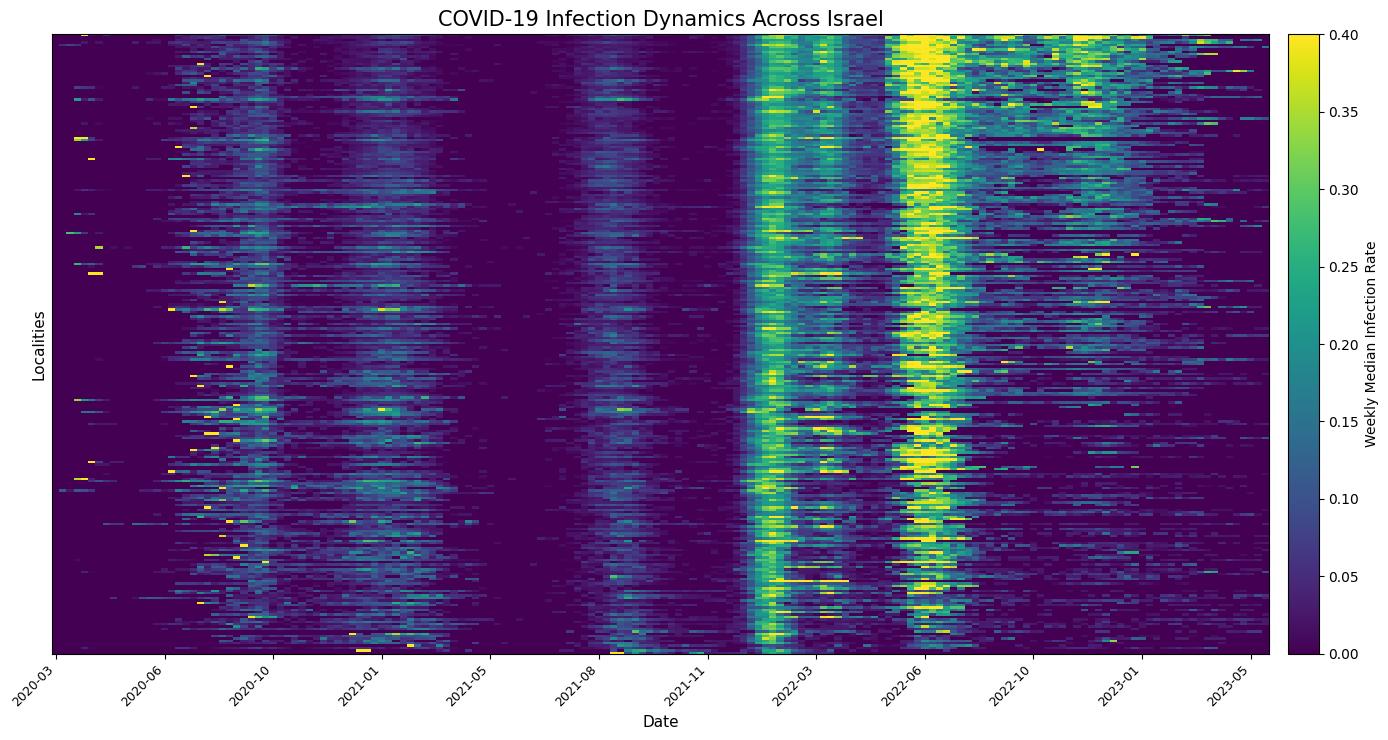

In [7]:
# ============================================================
# EDA: Whole-country weekly infection-rate heatmap
#
# Rows    = localities (towns)
# Columns = weeks
# Values  = median infection rate across statistical areas
#
# Designed to fit on a presentation slide
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

country_heat = df_loc_corona.reset_index().copy()

country_heat["date"] = pd.to_datetime(
    country_heat["date"],
    errors="coerce"
)

country_heat["infection_rate"] = pd.to_numeric(
    country_heat["infection_rate"],
    errors="coerce"
)

# Remove impossible infection-rate values
country_heat.loc[
    (country_heat["infection_rate"] < 0)
    | (country_heat["infection_rate"] > 1),
    "infection_rate"
] = np.nan


# ------------------------------------------------------------
# USE STATISTICAL AREAS ONLY
#
# Avoid mixing city aggregate (_0) rows with their
# constituent statistical areas.
# ------------------------------------------------------------

if "is_city_aggregate" in country_heat.columns:

    country_heat = country_heat[
        country_heat["is_city_aggregate"] == 0
    ].copy()


# ------------------------------------------------------------
# CREATE WEEK
# ------------------------------------------------------------

country_heat["week"] = (
    country_heat["date"]
    .dt.to_period("W")
    .dt.start_time
)


# ------------------------------------------------------------
# STEP 1:
# WEEKLY MEDIAN WITHIN EACH STATISTICAL AREA
# ------------------------------------------------------------

area_weekly = (
    country_heat
    .groupby(
        ["town", "City_agas_code", "week"]
    )["infection_rate"]
    .median()
    .reset_index()
)


# ------------------------------------------------------------
# STEP 2:
# MEDIAN ACROSS STATISTICAL AREAS WITHIN EACH TOWN
#
# This means each town gets ONE value per week.
# ------------------------------------------------------------

town_weekly = (
    area_weekly
    .groupby(
        ["town", "week"]
    )["infection_rate"]
    .median()
    .reset_index()
)


# ------------------------------------------------------------
# CREATE TOWN × WEEK MATRIX
# ------------------------------------------------------------

matrix = town_weekly.pivot_table(
    index="town",
    columns="week",
    values="infection_rate",
    aggfunc="median"
)

# Remove completely empty rows/columns
matrix = matrix.dropna(
    axis=0,
    how="all"
)

matrix = matrix.dropna(
    axis=1,
    how="all"
)


# ------------------------------------------------------------
# OPTIONAL:
# Require minimum temporal coverage
#
# Prevent towns with almost no observations from occupying
# rows in the heatmap.
# ------------------------------------------------------------

MIN_COVERAGE = 0.50

coverage = matrix.notna().mean(axis=1)

matrix = matrix.loc[
    coverage >= MIN_COVERAGE
]


# ------------------------------------------------------------
# SORT LOCALITIES
#
# Higher average infection burden at top
# ------------------------------------------------------------

town_order = (
    matrix
    .mean(axis=1)
    .sort_values(
        ascending=False
    )
    .index
)

matrix = matrix.loc[
    town_order
]


# ------------------------------------------------------------
# COLOR SCALE
#
# Robust upper limit prevents rare extreme values
# from flattening the rest of the colors.
# ------------------------------------------------------------

VMAX = np.nanquantile(
    matrix.values,
    0.99
)

print(
    f"Localities plotted: {len(matrix):,}"
)

print(
    f"Weeks plotted: {len(matrix.columns):,}"
)

print(
    f"Color scale maximum: {VMAX:.3f}"
)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 7.5)
)

im = ax.imshow(
    matrix.values,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=0,
    vmax=VMAX
)


# ------------------------------------------------------------
# X AXIS
# About 10–12 date labels
# ------------------------------------------------------------

n_weeks = len(matrix.columns)

x_step = max(
    1,
    n_weeks // 11
)

x_positions = np.arange(
    0,
    n_weeks,
    x_step
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    [
        matrix.columns[i].strftime("%Y-%m")
        for i in x_positions
    ],
    rotation=45,
    ha="right",
    fontsize=9
)


# ------------------------------------------------------------
# ------------------------------------------------------------
# Y AXIS
# Hide individual locality names for presentation clarity
# ------------------------------------------------------------

ax.set_yticks([])

ax.set_ylabel(
    f"Localities (n={len(matrix)})",
    fontsize=11
)


# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

ax.set_xlabel(
    "Date",
    fontsize=11
)

ax.set_ylabel(
    "Localities",
    fontsize=11
)

ax.set_title(
    "COVID-19 Infection Dynamics Across Israel",
    fontsize=15
)


# ------------------------------------------------------------
# COLORBAR
# ------------------------------------------------------------

cbar = plt.colorbar(
    im,
    ax=ax,
    pad=0.015,
    fraction=0.025
)

cbar.set_label(
    "Weekly Median Infection Rate",
    fontsize=10
)


plt.tight_layout()
plt.show()

Localities plotted: 260
Weeks plotted: 168
Color scale maximum: 0.400


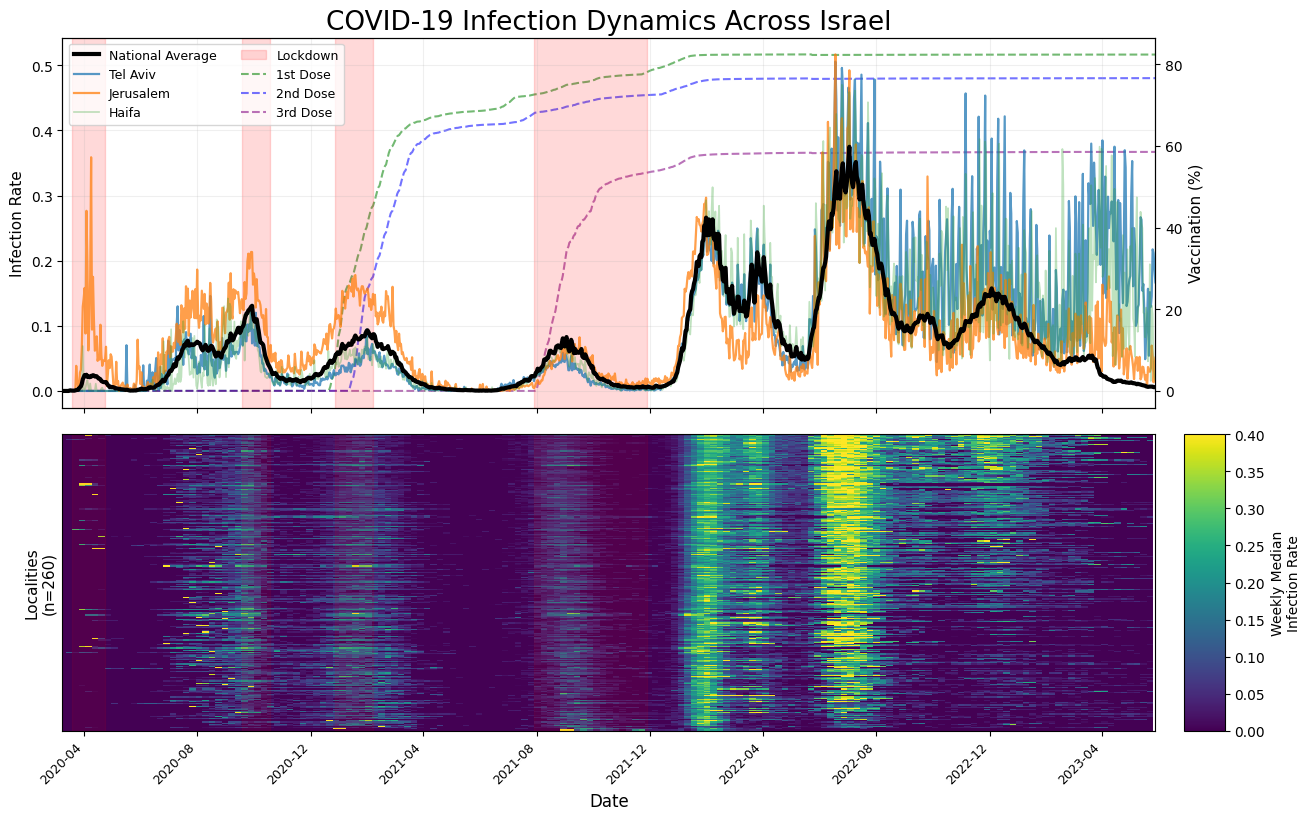

In [8]:
# ============================================================
# COMBINED EDA FIGURE
#
# TOP:
# National + Tel Aviv + Jerusalem + Haifa infection rates
# National vaccination trends + lockdown periods
#
# BOTTOM:
# Whole-country weekly infection-rate heatmap
#
# Presentation version:
# - Haifa is more transparent
# - National average is emphasized and drawn in front
# - Heatmap and upper plot share the same timeline
# - Dedicated colorbar keeps panels aligned
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec


# ============================================================
# PART 1: PREPARE TOP PANEL
# ============================================================

df_merged["date"] = pd.to_datetime(
    df_merged["date"],
    errors="coerce"
)


# ------------------------------------------------------------
# National trends
# ------------------------------------------------------------

national_trend = (
    df_merged
    .groupby("date")["infection_rate"]
    .mean()
)

vac_1_national_trend = (
    df_merged
    .groupby("date")["percent_vaccinated_first_dose"]
    .mean()
)

vac_2_national_trend = (
    df_merged
    .groupby("date")["percent_vaccinated_second_dose"]
    .mean()
)

vac_3_national_trend = (
    df_merged
    .groupby("date")["percent_vaccinated_third_dose"]
    .mean()
)


# ------------------------------------------------------------
# Selected cities
# ------------------------------------------------------------

selected_cities = [
    "5000_0",   # Tel Aviv
    "3000_0",   # Jerusalem
    "4000_0",   # Haifa
]

city_trends = {}

for city in selected_cities:

    city_data = df_merged[
        df_merged.index == city
    ].copy()

    city_data = city_data.sort_values(
        "date"
    )

    city_trends[city] = (
        city_data
        .set_index("date")["infection_rate"]
    )


# ------------------------------------------------------------
# Lockdown periods
# ------------------------------------------------------------

lockdown_periods = [
    ("2020-03-19", "2020-04-24"),
    ("2020-09-18", "2020-10-18"),
    ("2020-12-27", "2021-02-06"),
    ("2021-07-29", "2021-11-27"),
]

lockdown_periods = [
    (
        pd.to_datetime(start),
        pd.to_datetime(end)
    )
    for start, end in lockdown_periods
]


# ============================================================
# PART 2: PREPARE COUNTRY HEATMAP
# ============================================================

country_heat = (
    df_loc_corona
    .reset_index()
    .copy()
)

country_heat["date"] = pd.to_datetime(
    country_heat["date"],
    errors="coerce"
)

country_heat["infection_rate"] = pd.to_numeric(
    country_heat["infection_rate"],
    errors="coerce"
)


# Remove impossible infection-rate values
country_heat.loc[
    (country_heat["infection_rate"] < 0)
    | (country_heat["infection_rate"] > 1),
    "infection_rate"
] = np.nan


# ------------------------------------------------------------
# Statistical areas only
# Avoid mixing town aggregate rows with constituent areas
# ------------------------------------------------------------

if "is_city_aggregate" in country_heat.columns:

    country_heat = country_heat[
        country_heat["is_city_aggregate"] == 0
    ].copy()


# ------------------------------------------------------------
# Create weekly variable
# ------------------------------------------------------------

country_heat["week"] = (
    country_heat["date"]
    .dt.to_period("W")
    .dt.start_time
)


# ------------------------------------------------------------
# Weekly median within each statistical area
# ------------------------------------------------------------

area_weekly = (
    country_heat
    .groupby(
        [
            "town",
            "City_agas_code",
            "week"
        ]
    )["infection_rate"]
    .median()
    .reset_index()
)


# ------------------------------------------------------------
# Median across statistical areas within each locality
# ------------------------------------------------------------

town_weekly = (
    area_weekly
    .groupby(
        [
            "town",
            "week"
        ]
    )["infection_rate"]
    .median()
    .reset_index()
)


# ------------------------------------------------------------
# Town × week matrix
# ------------------------------------------------------------

matrix = town_weekly.pivot_table(
    index="town",
    columns="week",
    values="infection_rate",
    aggfunc="median"
)

matrix = matrix.dropna(
    axis=0,
    how="all"
)

matrix = matrix.dropna(
    axis=1,
    how="all"
)

matrix = matrix.sort_index(
    axis=1
)


# ------------------------------------------------------------
# Require reasonable temporal coverage
# ------------------------------------------------------------

MIN_COVERAGE = 0.50

coverage = (
    matrix
    .notna()
    .mean(axis=1)
)

matrix = matrix.loc[
    coverage >= MIN_COVERAGE
]


# ------------------------------------------------------------
# Sort localities by average infection burden
# ------------------------------------------------------------

town_order = (
    matrix
    .mean(axis=1)
    .sort_values(
        ascending=False
    )
    .index
)

matrix = matrix.loc[
    town_order
]


# ------------------------------------------------------------
# Robust heatmap color scale
# ------------------------------------------------------------

VMAX = np.nanquantile(
    matrix.values,
    0.99
)

print(
    f"Localities plotted: {len(matrix):,}"
)

print(
    f"Weeks plotted: {len(matrix.columns):,}"
)

print(
    f"Color scale maximum: {VMAX:.3f}"
)


# ============================================================
# PART 3: FIGURE LAYOUT
# ============================================================

fig = plt.figure(
    figsize=(15, 9)
)

gs = GridSpec(
    2,
    2,
    figure=fig,

    # Main plots + narrow colorbar column
    width_ratios=[40, 1.5],

    # Top plot slightly taller
    height_ratios=[1.25, 1],

    hspace=0.08,
    wspace=0.05
)


ax_top = fig.add_subplot(
    gs[0, 0]
)

ax_heat = fig.add_subplot(
    gs[1, 0],
    sharex=ax_top
)

# Separate colorbar axis
cax = fig.add_subplot(
    gs[1, 1]
)


# ============================================================
# PART 4: TOP PANEL
# ============================================================

# ------------------------------------------------------------
# Lockdowns FIRST — behind all curves
# ------------------------------------------------------------

for i, (start, end) in enumerate(
    lockdown_periods
):

    ax_top.axvspan(
        start,
        end,
        color="red",
        alpha=0.15,
        zorder=1,
        label="Lockdown" if i == 0 else None
    )


# ------------------------------------------------------------
# City styles
# ------------------------------------------------------------

city_styles = {

    "5000_0": {
        "label": "Tel Aviv",
        "alpha": 0.75,
        "linewidth": 1.6,
        "color": "tab:blue",
    },

    "3000_0": {
        "label": "Jerusalem",
        "alpha": 0.75,
        "linewidth": 1.6,
        "color": "tab:orange",
    },

    "4000_0": {
        "label": "Haifa",
        "alpha": 0.30,       # deliberately softer
        "linewidth": 1.25,
        "color": "tab:green",
    },
}


# ------------------------------------------------------------
# Plot city curves
# ------------------------------------------------------------

for city, series in city_trends.items():

    style = city_styles[city]

    ax_top.plot(
        series.index,
        series.values,

        label=style["label"],
        color=style["color"],
        linewidth=style["linewidth"],
        alpha=style["alpha"],

        zorder=4
    )


# ============================================================
# VACCINATION AXIS
# ============================================================

ax_vac = ax_top.twinx()


ax_vac.plot(
    vac_1_national_trend.index,
    vac_1_national_trend.values,

    label="1st Dose",
    color="green",
    linestyle="--",
    linewidth=1.5,
    alpha=0.55,

    zorder=2
)


ax_vac.plot(
    vac_2_national_trend.index,
    vac_2_national_trend.values,

    label="2nd Dose",
    color="blue",
    linestyle="--",
    linewidth=1.5,
    alpha=0.55,

    zorder=2
)


ax_vac.plot(
    vac_3_national_trend.index,
    vac_3_national_trend.values,

    label="3rd Dose",
    color="purple",
    linestyle="--",
    linewidth=1.5,
    alpha=0.55,

    zorder=2
)


ax_vac.set_ylabel(
    "Vaccination (%)",
    fontsize=11
)


# ------------------------------------------------------------
# Put infection-rate axis above vaccination axis
#
# This ensures the infection curves remain visually in front.
# ------------------------------------------------------------

ax_vac.set_zorder(1)
ax_top.set_zorder(2)

# Important:
# otherwise ax_top's background would hide the vaccination lines
ax_top.patch.set_visible(False)


# ============================================================
# NATIONAL AVERAGE
#
# Draw LAST, thick and completely opaque
# ============================================================

ax_top.plot(
    national_trend.index,
    national_trend.values,

    label="National Average",

    color="black",
    linewidth=3.0,
    alpha=1.0,

    zorder=10
)


# ------------------------------------------------------------
# Top-panel formatting
# ------------------------------------------------------------

ax_top.set_ylabel(
    "Infection Rate",
    fontsize=11
)

ax_top.set_title(
    "COVID-19 Infection Dynamics Across Israel",
    fontsize=19
)

ax_top.grid(
    alpha=0.20,
    zorder=0
)

# Bottom panel will display dates
ax_top.tick_params(
    axis="x",
    labelbottom=False
)


# ------------------------------------------------------------
# Combined legend
# ------------------------------------------------------------

handles1, labels1 = (
    ax_top.get_legend_handles_labels()
)

handles2, labels2 = (
    ax_vac.get_legend_handles_labels()
)


# Desired legend order
desired_order = [
    "National Average",
    "Tel Aviv",
    "Jerusalem",
    "Haifa",
    "Lockdown",
    "1st Dose",
    "2nd Dose",
    "3rd Dose",
]

handle_dict = dict(
    zip(
        labels1 + labels2,
        handles1 + handles2
    )
)

legend_handles = [
    handle_dict[label]
    for label in desired_order
    if label in handle_dict
]

legend_labels = [
    label
    for label in desired_order
    if label in handle_dict
]


ax_top.legend(
    legend_handles,
    legend_labels,

    loc="upper left",
    ncol=2,
    fontsize=9
)


# ============================================================
# PART 5: BOTTOM PANEL — COUNTRY HEATMAP
# ============================================================

week_dates = pd.to_datetime(
    matrix.columns
)

week_num = mdates.date2num(
    week_dates
)


# ------------------------------------------------------------
# Create weekly x-axis boundaries for pcolormesh
# ------------------------------------------------------------

if len(week_num) > 1:

    midpoints = (
        week_num[:-1]
        + week_num[1:]
    ) / 2

    x_edges = np.concatenate(
        [
            [
                week_num[0]
                - (
                    midpoints[0]
                    - week_num[0]
                )
            ],

            midpoints,

            [
                week_num[-1]
                + (
                    week_num[-1]
                    - midpoints[-1]
                )
            ]
        ]
    )

else:

    x_edges = np.array(
        [
            week_num[0] - 3.5,
            week_num[0] + 3.5
        ]
    )


y_edges = np.arange(
    len(matrix) + 1
)


# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

im = ax_heat.pcolormesh(

    x_edges,
    y_edges,

    np.ma.masked_invalid(
        matrix.values
    ),

    cmap="viridis",

    vmin=0,
    vmax=VMAX,

    shading="flat"
)


# Highest-burden localities at top
ax_heat.invert_yaxis()


# ------------------------------------------------------------
# Lockdowns on heatmap
# ------------------------------------------------------------

for start, end in lockdown_periods:

    ax_heat.axvspan(
        start,
        end,
        color="red",
        alpha=0.08
    )


# ------------------------------------------------------------
# Heatmap Y axis
# ------------------------------------------------------------

ax_heat.set_yticks([])

ax_heat.set_ylabel(
    f"Localities\n(n={len(matrix)})",
    fontsize=11
)


# ------------------------------------------------------------
# Shared time axis
# ------------------------------------------------------------

ax_heat.set_xlabel(
    "Date",
    fontsize=12
)

ax_heat.xaxis.set_major_locator(
    mdates.MonthLocator(
        interval=4
    )
)

ax_heat.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%Y-%m"
    )
)

plt.setp(
    ax_heat.get_xticklabels(),

    rotation=45,
    ha="right",
    fontsize=9
)


# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    im,
    cax=cax
)

cbar.set_label(
    "Weekly Median\nInfection Rate",
    fontsize=10
)


# ============================================================
# EXACTLY ALIGN TIME RANGE
# ============================================================

date_min = min(
    national_trend.index.min(),
    matrix.columns.min()
)

date_max = max(
    national_trend.index.max(),
    matrix.columns.max()
)

ax_heat.set_xlim(
    date_min,
    date_max
)


# ============================================================
# DISPLAY
# ============================================================

plt.show()

## 2.2 · Within-city heterogeneity
Median statistical area vs mean vs 25–75 % band, per city. The band widens sharply during waves; mean > median means a few areas run much hotter than the rest.

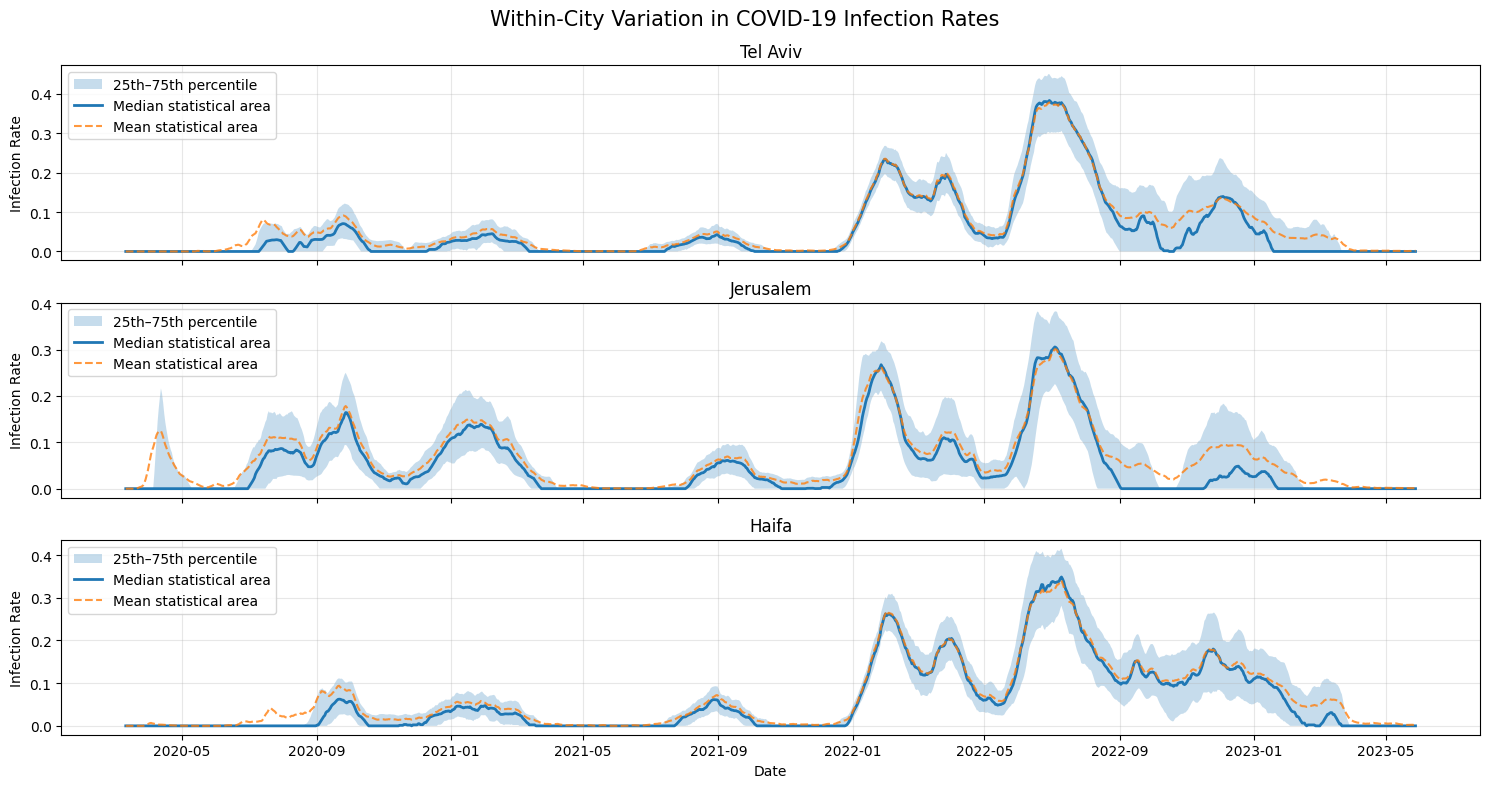

In [9]:
# ============================================================
# EDA: Within-city heterogeneity in infection rate over time
# Median across statistical areas + IQR (25th–75th percentile)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

CITY_COL = "town"   # <-- change if your city-name column has another name

CITIES = [
    "תל אביב-יפו",
    "ירושלים",
    "חיפה",
]

CITY_LABELS = {
    "תל אביב-יפו": "Tel Aviv",
    "ירושלים": "Jerusalem",
    "חיפה": "Haifa",
}

SMOOTHING_DAYS = 7


# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

plot_df = df_loc_corona[
    df_loc_corona[CITY_COL].isin(CITIES)
].copy()

plot_df["date"] = pd.to_datetime(plot_df["date"])

# Keep only sensible infection-rate values
plot_df.loc[
    (plot_df["infection_rate"] < 0) |
    (plot_df["infection_rate"] > 1),
    "infection_rate"
] = np.nan


# ------------------------------------------------------------
# CALCULATE DAILY DISTRIBUTION ACROSS STATISTICAL AREAS
# ------------------------------------------------------------

city_daily = (
    plot_df
    .groupby([CITY_COL, "date"])["infection_rate"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
        n_areas="count"
    )
    .reset_index()
)


# ------------------------------------------------------------
# OPTIONAL SMOOTHING
# ------------------------------------------------------------

city_daily = city_daily.sort_values([CITY_COL, "date"])

for col in ["median", "q25", "q75", "mean"]:
    city_daily[col + "_smooth"] = (
        city_daily
        .groupby(CITY_COL)[col]
        .transform(
            lambda x: x.rolling(
                SMOOTHING_DAYS,
                center=True,
                min_periods=1
            ).mean()
        )
    )


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(CITIES),
    1,
    figsize=(15, 8),
    sharex=True
)

if len(CITIES) == 1:
    axes = [axes]

for ax, city in zip(axes, CITIES):

    d = city_daily[
        city_daily[CITY_COL] == city
    ]

    # Interquartile range
    ax.fill_between(
        d["date"],
        d["q25_smooth"],
        d["q75_smooth"],
        alpha=0.25,
        label="25th–75th percentile"
    )

    # Median
    ax.plot(
        d["date"],
        d["median_smooth"],
        linewidth=2,
        label="Median statistical area"
    )

    # Mean
    ax.plot(
        d["date"],
        d["mean_smooth"],
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="Mean statistical area"
    )

    ax.set_title(CITY_LABELS.get(city, city))
    ax.set_ylabel("Infection Rate")

    ax.grid(
        alpha=0.3
    )

    ax.legend(
        loc="upper left"
    )


axes[-1].set_xlabel("Date")

fig.suptitle(
    "Within-City Variation in COVID-19 Infection Rates",
    fontsize=15
)

plt.tight_layout()
plt.show()

Number of statistical areas per locality:
town
תל אביב-יפו    112
ירושלים        148
חיפה            71
Name: City_agas_code, dtype: int64

Number of weekly observations:
town
תל אביב-יפו    18816
ירושלים        24864
חיפה           11928
Name: infection_rate, dtype: int64

Common heatmap maximum: 0.405


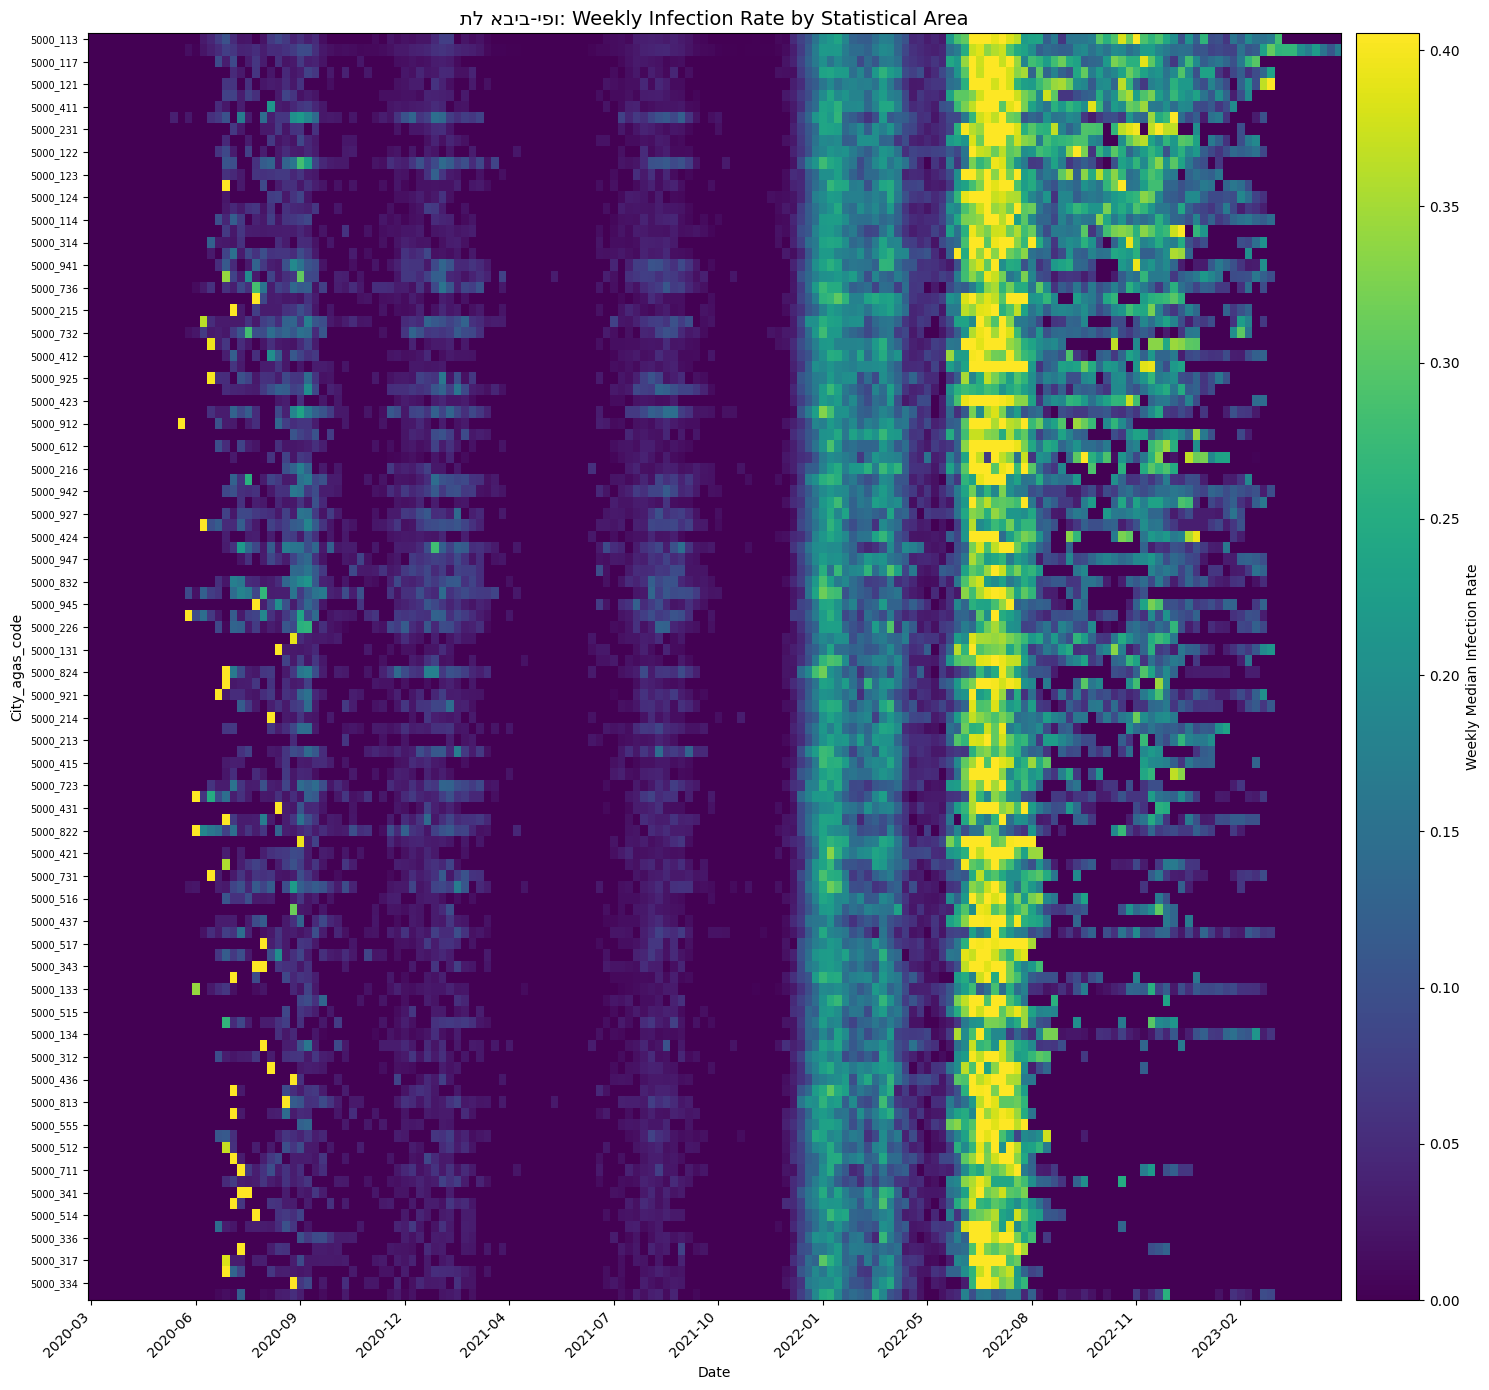

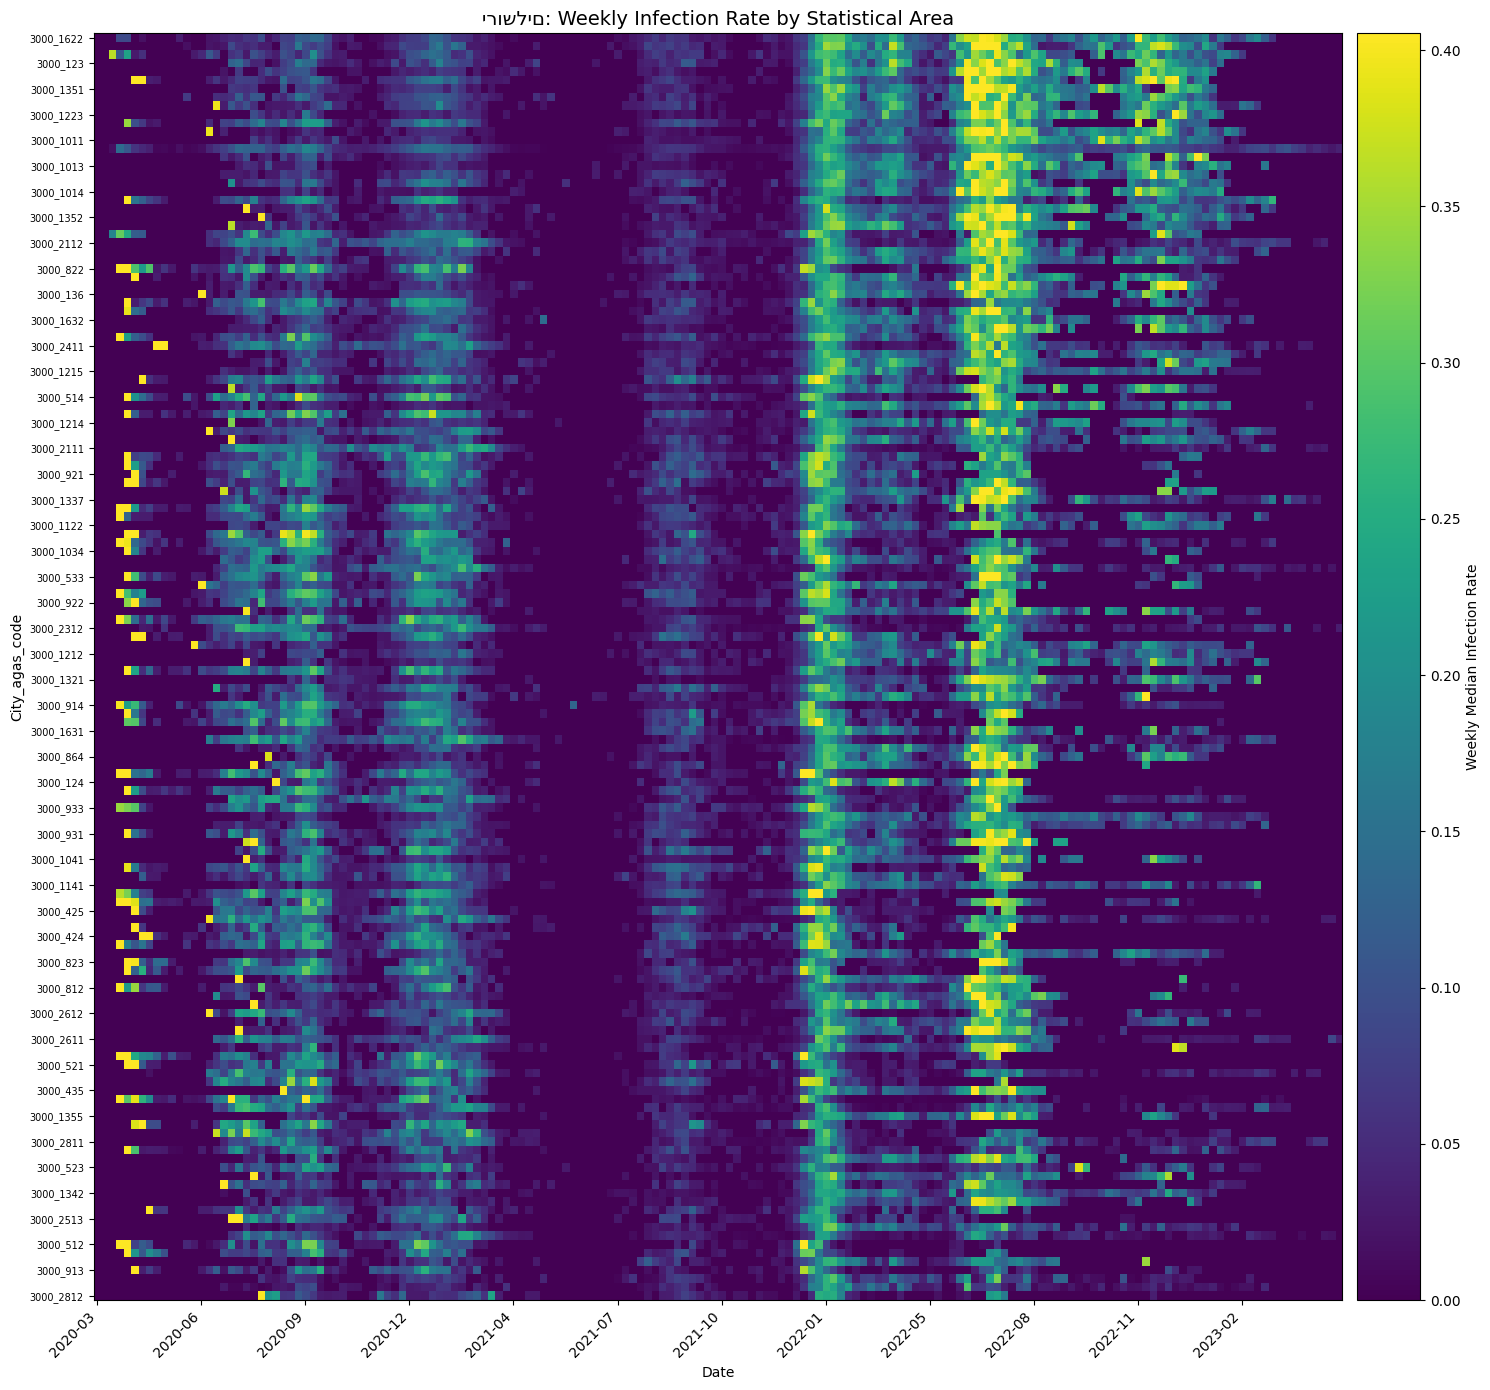

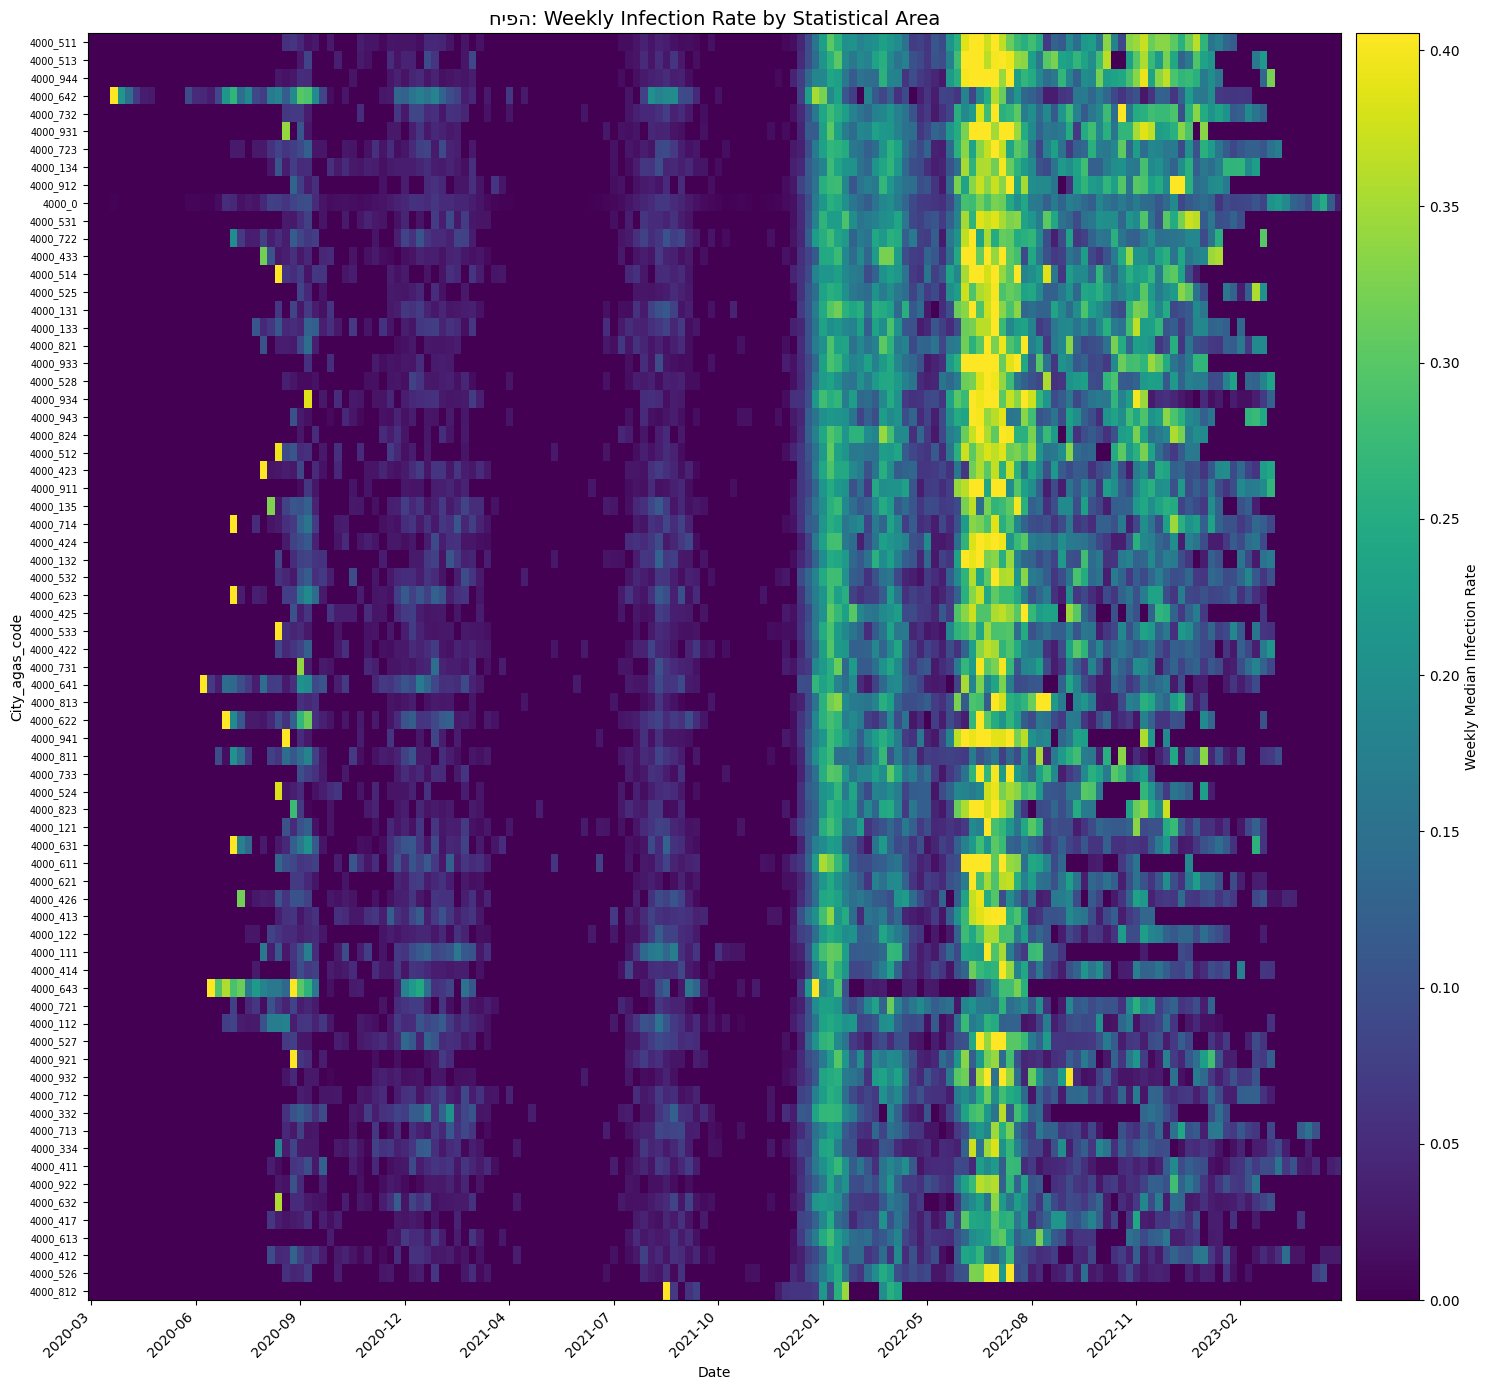

In [10]:
# ============================================================
# EDA: Weekly infection-rate heatmap by statistical area
# Uses the same cities and plot_df from the previous cell
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# PREPARE WEEKLY DATA
# ------------------------------------------------------------

heat_df = plot_df.copy()

heat_df["date"] = pd.to_datetime(
    heat_df["date"],
    errors="coerce"
)

heat_df["infection_rate"] = pd.to_numeric(
    heat_df["infection_rate"],
    errors="coerce"
)

# Remove impossible infection-rate values
heat_df.loc[
    (heat_df["infection_rate"] < 0)
    | (heat_df["infection_rate"] > 1),
    "infection_rate"
] = np.nan


# Assign each date to a week
heat_df["week"] = (
    heat_df["date"]
    .dt.to_period("W")
    .dt.start_time
)


# ------------------------------------------------------------
# WEEKLY MEDIAN INFECTION RATE
# FOR EACH STATISTICAL AREA
# ------------------------------------------------------------

weekly_area = (
    heat_df
    .groupby(
        ["town", "City_agas_code", "week"]
    )["infection_rate"]
    .median()
    .reset_index()
)


# ------------------------------------------------------------
# DIAGNOSTICS
# ------------------------------------------------------------

print("Number of statistical areas per locality:")
print(
    weekly_area
    .groupby("town")["City_agas_code"]
    .nunique()
    .reindex(CITIES)
)

print("\nNumber of weekly observations:")
print(
    weekly_area
    .groupby("town")["infection_rate"]
    .count()
    .reindex(CITIES)
)


# ------------------------------------------------------------
# USE ONE COMMON COLOR SCALE FOR ALL CITIES
# ------------------------------------------------------------

# 99th percentile prevents a few extreme observations
# from making the whole heatmap look dark.
VMAX = weekly_area["infection_rate"].quantile(0.99)

print(f"\nCommon heatmap maximum: {VMAX:.3f}")


# ------------------------------------------------------------
# HEATMAP FUNCTION
# ------------------------------------------------------------

def plot_city_heatmap(city):

    city_data = weekly_area[
        weekly_area["town"] == city
    ].copy()

    if city_data.empty:
        print(f"No data found for {city}")
        return

    # Rows = statistical areas
    # Columns = weeks
    matrix = city_data.pivot_table(
        index="City_agas_code",
        columns="week",
        values="infection_rate",
        aggfunc="median"
    )

    # Remove rows/columns containing only NaN
    matrix = matrix.dropna(
        axis=0,
        how="all"
    )

    matrix = matrix.dropna(
        axis=1,
        how="all"
    )

    if matrix.empty:
        print(f"No usable infection-rate data for {city}")
        return


    # --------------------------------------------------------
    # SORT AREAS
    # Highest average infection rate at the top
    # --------------------------------------------------------

    area_mean = matrix.mean(axis=1)

    area_order = (
        area_mean
        .sort_values(ascending=False)
        .index
    )

    matrix = matrix.loc[area_order]


    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    fig_height = max(
        3,
        min(14, len(matrix) * 0.22 + 2)
    )

    fig, ax = plt.subplots(
        figsize=(16, fig_height)
    )

    im = ax.imshow(
        matrix.values,
        aspect="auto",
        interpolation="nearest",
        vmin=0,
        vmax=VMAX,
        cmap="viridis"
    )


    # --------------------------------------------------------
    # Y AXIS
    # --------------------------------------------------------

    # Avoid too many labels for large cities
    y_step = max(
        1,
        len(matrix.index) // 40
    )

    y_positions = np.arange(
        0,
        len(matrix.index),
        y_step
    )

    ax.set_yticks(y_positions)

    ax.set_yticklabels(
        matrix.index[y_positions],
        fontsize=7
    )


    # --------------------------------------------------------
    # X AXIS
    # --------------------------------------------------------

    n_weeks = len(matrix.columns)

    # Approximately 12 date labels
    x_step = max(
        1,
        n_weeks // 12
    )

    x_positions = np.arange(
        0,
        n_weeks,
        x_step
    )

    ax.set_xticks(x_positions)

    ax.set_xticklabels(
        [
            matrix.columns[i].strftime("%Y-%m")
            for i in x_positions
        ],
        rotation=45,
        ha="right"
    )


    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    ax.set_title(
        f"{city}: Weekly Infection Rate by Statistical Area",
        fontsize=14
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("City_agas_code")

    cbar = plt.colorbar(
        im,
        ax=ax,
        pad=0.01
    )

    cbar.set_label(
        "Weekly Median Infection Rate"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# PLOT ALL SELECTED LOCALITIES
# ------------------------------------------------------------

for city in CITIES:
    plot_city_heatmap(city)

## 2.3 · Testing behaviour
The infection rate is `cases/tests`, so it is only as stable as the test count. Low-volume area-days give unstable / zero rates; testing intensity itself rises around waves. Testing must therefore be an explicit model input.

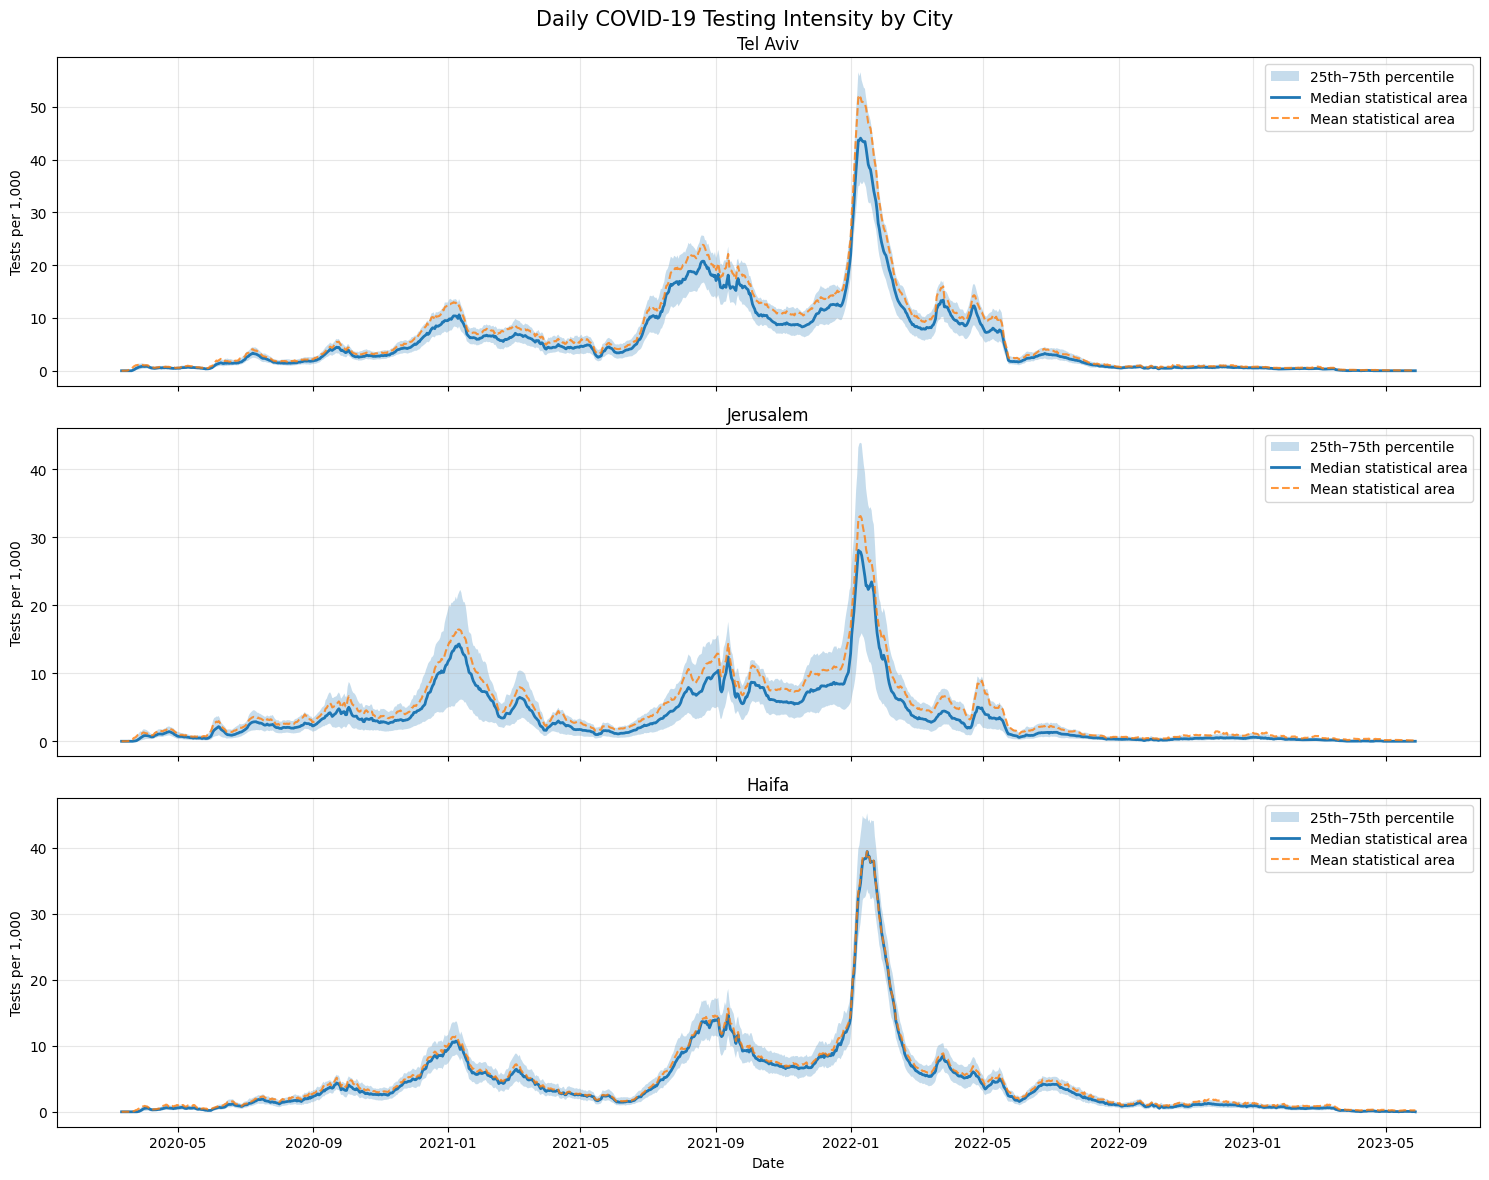

In [11]:
# ============================================================
# EDA: Panic index over time by city
# Median across statistical areas + IQR (25th–75th percentile)
#
# panic_index = daily tests per 1,000 residents
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

CITY_COL = "town"

CITIES = [
    "תל אביב-יפו",
    "ירושלים",
    "חיפה"
]

CITY_LABELS = {
    "תל אביב-יפו": "Tel Aviv",
    "ירושלים": "Jerusalem",
    "חיפה": "Haifa",
}

SMOOTHING_DAYS = 7


# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

panic_df = df_merged[
    df_merged[CITY_COL].isin(CITIES)
].copy()

panic_df["date"] = pd.to_datetime(
    panic_df["date"],
    errors="coerce"
)

panic_df["panic_index"] = pd.to_numeric(
    panic_df["panic_index"],
    errors="coerce"
)


# Negative testing intensity is not meaningful
# and may result from retrospective corrections
panic_df.loc[
    panic_df["panic_index"] < 0,
    "panic_index"
] = np.nan


# ------------------------------------------------------------
# DAILY DISTRIBUTION ACROSS STATISTICAL AREAS
# ------------------------------------------------------------

panic_daily = (
    panic_df
    .groupby([CITY_COL, "date"])["panic_index"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
        n_areas="count"
    )
    .reset_index()
)


# ------------------------------------------------------------
# 7-DAY SMOOTHING
# ------------------------------------------------------------

panic_daily = panic_daily.sort_values(
    [CITY_COL, "date"]
)

for col in ["median", "q25", "q75", "mean"]:

    panic_daily[f"{col}_smooth"] = (
        panic_daily
        .groupby(CITY_COL)[col]
        .transform(
            lambda x: x.rolling(
                window=SMOOTHING_DAYS,
                center=True,
                min_periods=1
            ).mean()
        )
    )


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(CITIES),
    1,
    figsize=(15, 12),
    sharex=True
)

if len(CITIES) == 1:
    axes = [axes]


for ax, city in zip(axes, CITIES):

    d = panic_daily[
        panic_daily[CITY_COL] == city
    ]

    # IQR: middle 50% of statistical areas
    ax.fill_between(
        d["date"],
        d["q25_smooth"],
        d["q75_smooth"],
        alpha=0.25,
        label="25th–75th percentile"
    )

    # Median statistical area
    ax.plot(
        d["date"],
        d["median_smooth"],
        linewidth=2,
        label="Median statistical area"
    )

    # Mean statistical area
    ax.plot(
        d["date"],
        d["mean_smooth"],
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="Mean statistical area"
    )

    ax.set_title(CITY_LABELS.get(city, city))
    ax.set_ylabel(
        "Tests per 1,000"
    )

    ax.grid(alpha=0.3)

    ax.legend(
        loc="upper right"
    )


axes[-1].set_xlabel("Date")

fig.suptitle(
    "Daily COVID-19 Testing Intensity by City",
    fontsize=15
)

plt.tight_layout()
plt.show()

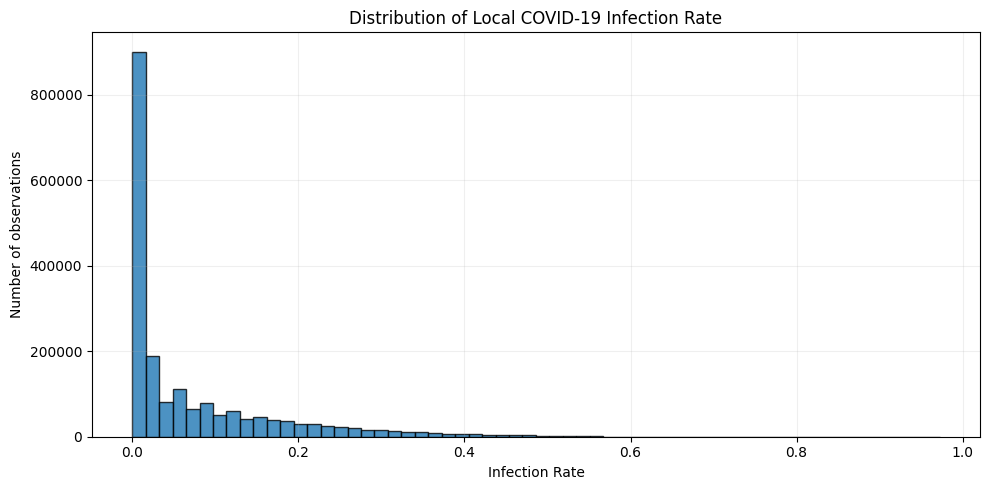

INFECTION RATE SUMMARY
----------------------
count    1.942906e+06
mean     7.056047e-02
std      1.027470e-01
min      0.000000e+00
25%      0.000000e+00
50%      2.439024e-02
75%      1.052632e-01
90%      2.222222e-01
95%      2.941176e-01
99%      4.358974e-01
max      9.722222e-01
Name: infection_rate, dtype: float64

Exactly zero: 859,313 (44.23%)
Missing: 0 (0.00%)


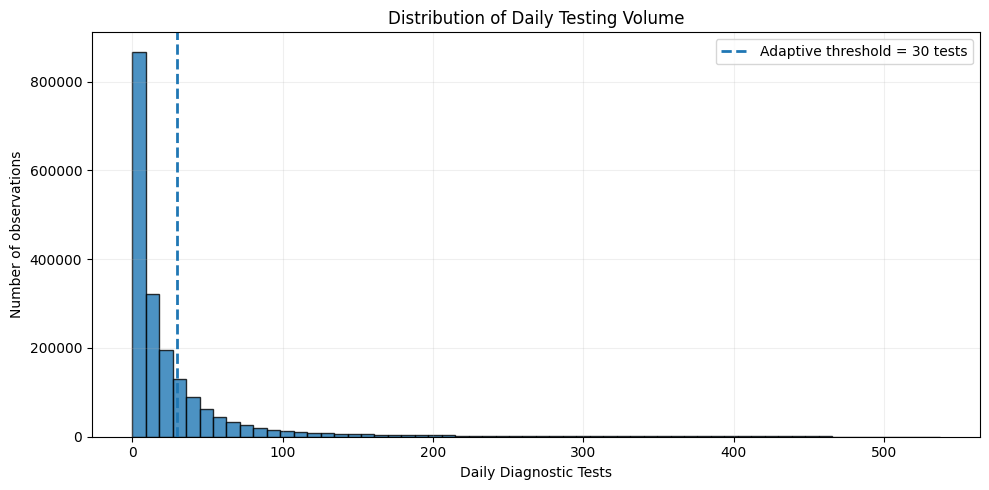


INFECTION RATE BY TESTING VOLUME
--------------------------------
  testing_bin  n_rows  median_infection_rate  mean_infection_rate  \
0         0–4  628722                 0.0000               0.0514   
1         5–9  284760                 0.0312               0.0855   
2       10–19  326743                 0.0299               0.0818   
3       20–29  193123                 0.0303               0.0733   
4       30–49  208565                 0.0294               0.0675   
5       50–99  165433                 0.0392               0.0770   
6     100–249   89105                 0.0654               0.0968   
7        250+   46455                 0.0581               0.0877   

   zero_fraction  
0         0.6481  
1         0.4252  
2         0.4009  
3         0.3517  
4         0.3822  
5         0.2395  
6         0.1135  
7         0.0525  


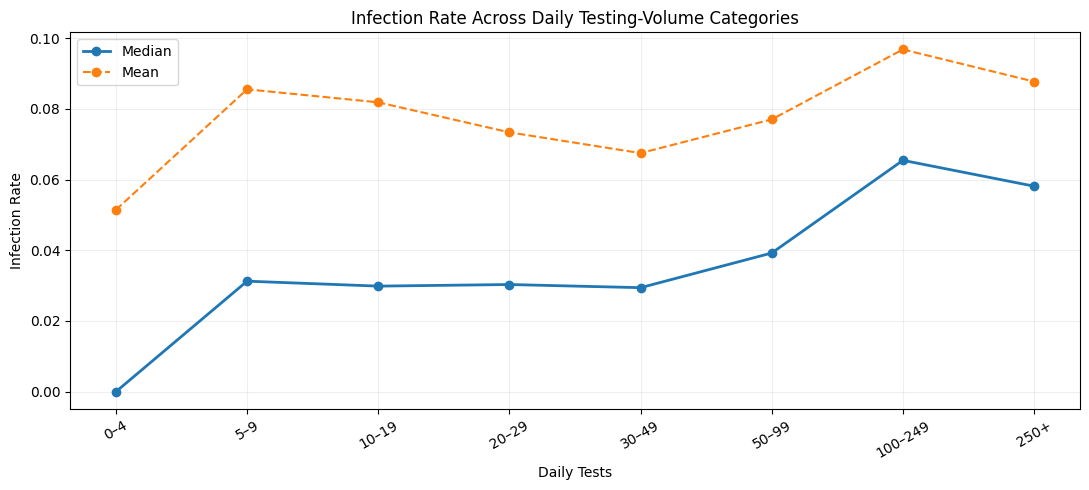

In [12]:
# ============================================================
# EDA: Target distribution + testing-volume diagnostics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

eda_target = df_loc_corona.copy()

eda_target["infection_rate"] = pd.to_numeric(
    eda_target["infection_rate"],
    errors="coerce"
)

eda_target["tested_daily"] = pd.to_numeric(
    eda_target["tested_daily"],
    errors="coerce"
)

# Keep valid infection rates
eda_target.loc[
    (eda_target["infection_rate"] < 0)
    | (eda_target["infection_rate"] > 1),
    "infection_rate"
] = np.nan

# Negative daily tests are likely corrections / artifacts
eda_target.loc[
    eda_target["tested_daily"] < 0,
    "tested_daily"
] = np.nan


# ============================================================
# 1. DISTRIBUTION OF INFECTION RATE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    eda_target["infection_rate"].dropna(),
    bins=60,
    edgecolor="black",
    alpha=0.8
)

ax.set_xlabel("Infection Rate")
ax.set_ylabel("Number of observations")

ax.set_title(
    "Distribution of Local COVID-19 Infection Rate"
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# PRINT BASIC TARGET STATISTICS
# ------------------------------------------------------------

valid_rate = eda_target["infection_rate"].dropna()

print("INFECTION RATE SUMMARY")
print("----------------------")

print(valid_rate.describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
))

print(
    f"\nExactly zero: "
    f"{(valid_rate == 0).sum():,} "
    f"({(valid_rate == 0).mean()*100:.2f}%)"
)

print(
    f"Missing: "
    f"{eda_target['infection_rate'].isna().sum():,} "
    f"({eda_target['infection_rate'].isna().mean()*100:.2f}%)"
)


# ============================================================
# 2. DISTRIBUTION OF DAILY TESTING VOLUME
# ============================================================

# Use 99th percentile so extreme test days do not squash the plot
test_upper = eda_target["tested_daily"].quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    eda_target.loc[
        eda_target["tested_daily"] <= test_upper,
        "tested_daily"
    ].dropna(),
    bins=60,
    edgecolor="black",
    alpha=0.8
)

ax.axvline(
    30,
    linestyle="--",
    linewidth=2,
    label="Adaptive threshold = 30 tests"
)

ax.set_xlabel("Daily Diagnostic Tests")
ax.set_ylabel("Number of observations")

ax.set_title(
    "Distribution of Daily Testing Volume"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ============================================================
# 3. INFECTION RATE BY TESTING-VOLUME BIN
# ============================================================

test_bins = [
    0,
    5,
    10,
    20,
    30,
    50,
    100,
    250,
    np.inf
]

test_labels = [
    "0–4",
    "5–9",
    "10–19",
    "20–29",
    "30–49",
    "50–99",
    "100–249",
    "250+"
]

eda_target["testing_bin"] = pd.cut(
    eda_target["tested_daily"],
    bins=test_bins,
    labels=test_labels,
    right=False
)


testing_summary = (
    eda_target
    .groupby("testing_bin", observed=False)
    .agg(
        n_rows=("infection_rate", "size"),
        median_infection_rate=("infection_rate", "median"),
        mean_infection_rate=("infection_rate", "mean"),
        zero_fraction=(
            "infection_rate",
            lambda x: (x == 0).mean()
        )
    )
    .reset_index()
)

print("\nINFECTION RATE BY TESTING VOLUME")
print("--------------------------------")

print(
    testing_summary.round(4)
)


fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    testing_summary["testing_bin"].astype(str),
    testing_summary["median_infection_rate"],
    marker="o",
    linewidth=2,
    label="Median"
)

ax.plot(
    testing_summary["testing_bin"].astype(str),
    testing_summary["mean_infection_rate"],
    marker="o",
    linestyle="--",
    linewidth=1.5,
    label="Mean"
)

ax.set_xlabel("Daily Tests")
ax.set_ylabel("Infection Rate")

ax.set_title(
    "Infection Rate Across Daily Testing-Volume Categories"
)

ax.grid(alpha=0.2)
ax.legend()

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 2.4 · Temporal persistence — does the recent past carry signal?
Spearman autocorrelation stays high for 1–7 days and is still material at 2–4 weeks; lagged testing intensity is also positively associated with future infection. This is what justifies lag / rolling features and a sequence model.

lag_days        0      3      7      14     21     28
town                                                 
חיפה         0.253  0.262  0.271  0.279  0.280  0.277
ירושלים      0.518  0.527  0.537  0.542  0.536  0.527
תל אביב-יפו  0.246  0.257  0.270  0.286  0.294  0.293


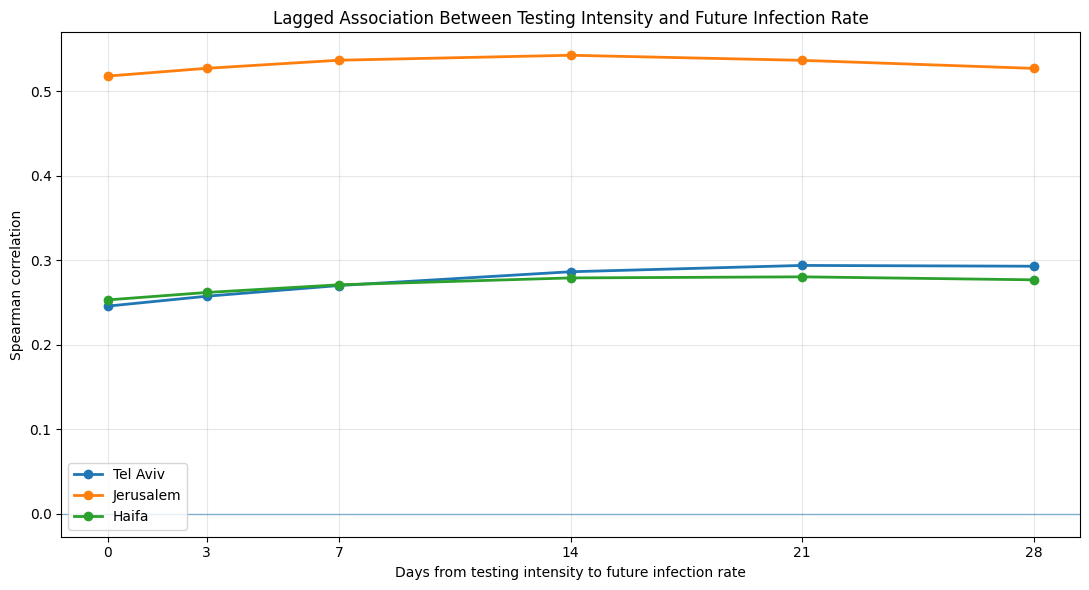

In [13]:
# ============================================================
# EDA: Does testing intensity precede infection rate?
# Spearman correlation between panic_index(t)
# and infection_rate(t + lag)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

CITIES_LAG = [
    "תל אביב-יפו",
    "ירושלים",
    "חיפה"
]

CITY_LABELS = {
    "תל אביב-יפו": "Tel Aviv",
    "ירושלים": "Jerusalem",
    "חיפה": "Haifa",
}

LAGS = [0, 3, 7, 14, 21, 28]

SMOOTHING_DAYS = 7


# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

lag_df = df_merged[
    df_merged["town"].isin(CITIES_LAG)
].copy()

lag_df["date"] = pd.to_datetime(
    lag_df["date"],
    errors="coerce"
)

lag_df["infection_rate"] = pd.to_numeric(
    lag_df["infection_rate"],
    errors="coerce"
)

lag_df["panic_index"] = pd.to_numeric(
    lag_df["panic_index"],
    errors="coerce"
)

# Remove invalid values
lag_df.loc[
    (lag_df["infection_rate"] < 0)
    | (lag_df["infection_rate"] > 1),
    "infection_rate"
] = np.nan

lag_df.loc[
    lag_df["panic_index"] < 0,
    "panic_index"
] = np.nan


# ------------------------------------------------------------
# ONE DAILY VALUE PER CITY
# Use median across statistical areas
# ------------------------------------------------------------

city_daily = (
    lag_df
    .groupby(["town", "date"])
    .agg(
        infection_rate=("infection_rate", "median"),
        panic_index=("panic_index", "median")
    )
    .reset_index()
    .sort_values(["town", "date"])
)


# ------------------------------------------------------------
# 7-DAY SMOOTHING
# ------------------------------------------------------------

for col in ["infection_rate", "panic_index"]:

    city_daily[f"{col}_smooth"] = (
        city_daily
        .groupby("town")[col]
        .transform(
            lambda x: x.rolling(
                SMOOTHING_DAYS,
                center=True,
                min_periods=1
            ).mean()
        )
    )


# ------------------------------------------------------------
# CALCULATE LAGGED SPEARMAN CORRELATIONS
#
# Question:
# Does panic_index today correlate with
# infection_rate X days in the future?
# ------------------------------------------------------------

results = []

for city in CITIES_LAG:

    d = city_daily[
        city_daily["town"] == city
    ][
        [
            "date",
            "panic_index_smooth",
            "infection_rate_smooth"
        ]
    ].copy()

    for lag in LAGS:

        # Future infection-rate table
        future = d[
            ["date", "infection_rate_smooth"]
        ].copy()

        # Shift the DATE backward so infection at t+lag
        # lines up with panic at time t
        future["date"] = (
            future["date"]
            - pd.Timedelta(days=lag)
        )

        future = future.rename(
            columns={
                "infection_rate_smooth":
                "future_infection_rate"
            }
        )

        merged_lag = d[
            ["date", "panic_index_smooth"]
        ].merge(
            future,
            on="date",
            how="inner"
        )

        merged_lag = merged_lag.dropna()

        if len(merged_lag) >= 10:

            rho = merged_lag[
                [
                    "panic_index_smooth",
                    "future_infection_rate"
                ]
            ].corr(
                method="spearman"
            ).iloc[0, 1]

        else:
            rho = np.nan

        results.append({
            "town": city,
            "lag_days": lag,
            "spearman_rho": rho,
            "n": len(merged_lag)
        })


lag_results = pd.DataFrame(results)


# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print(
    lag_results
    .pivot(
        index="town",
        columns="lag_days",
        values="spearman_rho"
    )
    .round(3)
)


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6)
)

for city in CITIES_LAG:

    d = lag_results[
        lag_results["town"] == city
    ]

    ax.plot(
        d["lag_days"],
        d["spearman_rho"],
        marker="o",
        linewidth=2,
        label=CITY_LABELS.get(city, city)
    )


ax.axhline(
    0,
    linewidth=1,
    alpha=0.5
)

ax.set_xlabel(
    "Days from testing intensity to future infection rate"
)

ax.set_ylabel(
    "Spearman correlation"
)

ax.set_title(
    "Lagged Association Between Testing Intensity and Future Infection Rate"
)

ax.set_xticks(LAGS)

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()

Median autocorrelation across statistical areas:

lag_days        1      3      7      14     21     28
town                                                 
תל אביב-יפו  0.884  0.795  0.727  0.650  0.600  0.537
ירושלים      0.890  0.803  0.722  0.624  0.550  0.464
חיפה         0.907  0.824  0.768  0.709  0.656  0.605


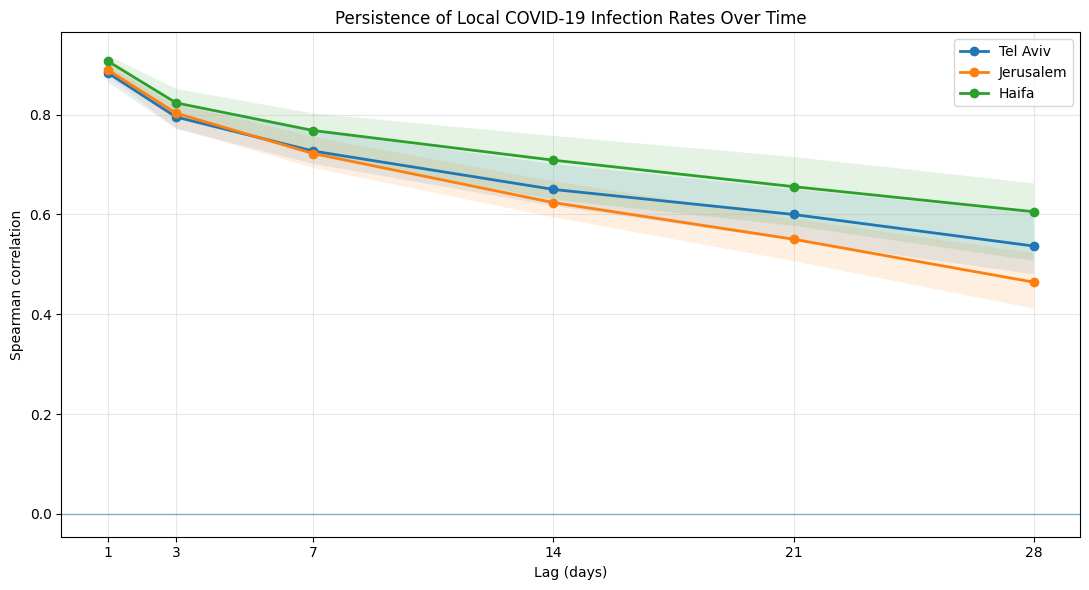

In [14]:
# ============================================================
# EDA: Temporal persistence of infection rate
# Spearman correlation between infection_rate(t)
# and infection_rate(t + lag)
#
# Calculated separately for every statistical area,
# then summarized by city.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

CITIES_EDA = [
    "תל אביב-יפו",
    "ירושלים",
    "חיפה"
]

CITY_LABELS = {
    "תל אביב-יפו": "Tel Aviv",
    "ירושלים": "Jerusalem",
    "חיפה": "Haifa",
}

LAGS = [1, 3, 7, 14, 21, 28]

MIN_PAIRS = 30

# ============================================================
# PREPARE DATA
# City_agas_code is stored in the index
# ============================================================

auto_df = df_loc_corona.reset_index().copy()

auto_df = auto_df[
    auto_df["town"].isin(CITIES_EDA)
][
    [
        "town",
        "City_agas_code",
        "date",
        "infection_rate"
    ]
].copy()

auto_df["date"] = pd.to_datetime(
    auto_df["date"],
    errors="coerce"
)

auto_df["infection_rate"] = pd.to_numeric(
    auto_df["infection_rate"],
    errors="coerce"
)

# Remove invalid values
auto_df.loc[
    (auto_df["infection_rate"] < 0)
    | (auto_df["infection_rate"] > 1),
    "infection_rate"
] = np.nan

auto_df = auto_df.dropna(
    subset=[
        "City_agas_code",
        "date",
        "infection_rate"
    ]
)

auto_df = auto_df.sort_values(
    ["City_agas_code", "date"]
)


# ------------------------------------------------------------
# CALCULATE CORRELATION FOR EACH STATISTICAL AREA
# ------------------------------------------------------------

results = []

for (town, area), d in auto_df.groupby(
    ["town", "City_agas_code"]
):

    d = (
        d[["date", "infection_rate"]]
        .drop_duplicates("date")
        .sort_values("date")
    )

    for lag in LAGS:

        # infection rate at time t
        current = d.rename(
            columns={
                "infection_rate": "infection_t"
            }
        )

        # infection rate at time t + lag
        future = d.copy()

        future["date"] = (
            future["date"]
            - pd.Timedelta(days=lag)
        )

        future = future.rename(
            columns={
                "infection_rate":
                "infection_future"
            }
        )

        paired = current.merge(
            future,
            on="date",
            how="inner"
        )

        paired = paired.dropna(
            subset=[
                "infection_t",
                "infection_future"
            ]
        )

        if (
            len(paired) >= MIN_PAIRS
            and paired["infection_t"].nunique() > 1
            and paired["infection_future"].nunique() > 1
        ):

            rho = paired[
                [
                    "infection_t",
                    "infection_future"
                ]
            ].corr(
                method="spearman"
            ).iloc[0, 1]

        else:
            rho = np.nan

        results.append({
            "town": town,
            "City_agas_code": area,
            "lag_days": lag,
            "spearman_rho": rho,
            "n_pairs": len(paired)
        })


autocorr_area = pd.DataFrame(results)


# ------------------------------------------------------------
# SUMMARIZE ACROSS STATISTICAL AREAS WITHIN EACH CITY
# ------------------------------------------------------------

autocorr_city = (
    autocorr_area
    .groupby(["town", "lag_days"])["spearman_rho"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
        n_areas="count"
    )
    .reset_index()
)


# ------------------------------------------------------------
# PRINT TABLE
# ------------------------------------------------------------

print("Median autocorrelation across statistical areas:\n")

print(
    autocorr_city
    .pivot(
        index="town",
        columns="lag_days",
        values="median"
    )
    .reindex(CITIES_EDA)
    .round(3)
)


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6)
)

for city in CITIES_EDA:

    d = autocorr_city[
        autocorr_city["town"] == city
    ]

    if d.empty:
        continue

    ax.plot(
        d["lag_days"],
        d["median"],
        marker="o",
        linewidth=2,
        label=CITY_LABELS.get(city, city)
    )

    # IQR across statistical areas
    ax.fill_between(
        d["lag_days"],
        d["q25"],
        d["q75"],
        alpha=0.12
    )


ax.axhline(
    0,
    linewidth=1,
    alpha=0.5
)

ax.set_xlabel(
    "Lag (days)"
)

ax.set_ylabel(
    "Spearman correlation"
)

ax.set_title(
    "Persistence of Local COVID-19 Infection Rates Over Time"
)

ax.set_xticks(LAGS)

ax.grid(
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

## 2.5 · Naive persistence baseline
`infection_rate(t+h) = infection_rate(t)`. This MAE-by-horizon curve is the bar the ML models in notebooks 04–05 have to clear to be worth anything.

NAIVE PERSISTENCE BASELINE
--------------------------
   horizon_days  median_MAE  median_RMSE  median_rho  n_areas
0             1      0.0218       0.0446      0.8997     1576
1             3      0.0343       0.0639      0.8153     1576
2             7      0.0419       0.0757      0.7469     1576
3            14      0.0501       0.0866      0.6654     1576
4            21      0.0564       0.0956      0.5997     1576
5            28      0.0627       0.1039      0.5311     1576


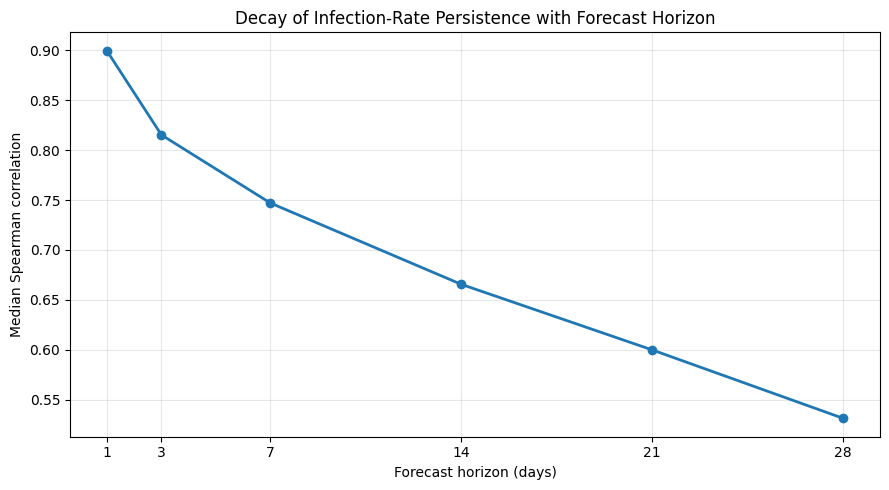

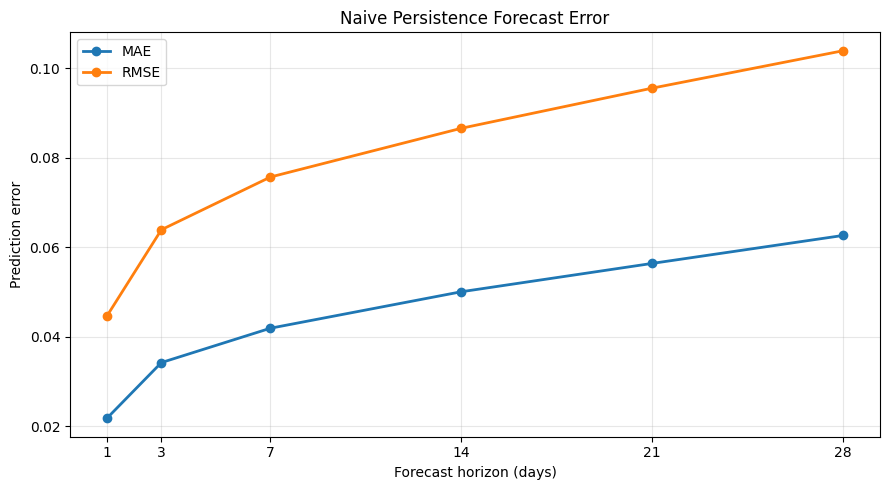

In [15]:
# ============================================================
# EDA / BASELINE:
# Persistence forecast performance
#
# Naive prediction:
# infection_rate(t + horizon) = infection_rate(t)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

HORIZONS = [
    1,
    3,
    7,
    14,
    21,
    28
]


# ------------------------------------------------------------
# PREPARE AREA-LEVEL DATA
# ------------------------------------------------------------

persist_df = df_loc_corona.reset_index().copy()

persist_df["date"] = pd.to_datetime(
    persist_df["date"],
    errors="coerce"
)

persist_df["infection_rate"] = pd.to_numeric(
    persist_df["infection_rate"],
    errors="coerce"
)

# Use statistical areas only
if "is_city_aggregate" in persist_df.columns:

    persist_df = persist_df[
        persist_df["is_city_aggregate"] == 0
    ].copy()


persist_df.loc[
    (persist_df["infection_rate"] < 0)
    | (persist_df["infection_rate"] > 1),
    "infection_rate"
] = np.nan


persist_df = persist_df[
    [
        "City_agas_code",
        "town",
        "date",
        "infection_rate"
    ]
].dropna()


# ------------------------------------------------------------
# CALCULATE NAIVE FORECAST PERFORMANCE
# SEPARATELY FOR EACH AREA
# ------------------------------------------------------------

results = []


for (town, area), d in persist_df.groupby(
    ["town", "City_agas_code"]
):

    d = (
        d[
            ["date", "infection_rate"]
        ]
        .drop_duplicates("date")
        .sort_values("date")
    )


    for horizon in HORIZONS:

        # Current infection rate = prediction
        current = d.rename(
            columns={
                "infection_rate":
                "prediction"
            }
        )


        # Actual future infection rate
        future = d.copy()

        future["date"] = (
            future["date"]
            - pd.Timedelta(
                days=horizon
            )
        )

        future = future.rename(
            columns={
                "infection_rate":
                "actual"
            }
        )


        paired = current.merge(
            future,
            on="date",
            how="inner"
        )

        paired = paired.dropna(
            subset=[
                "prediction",
                "actual"
            ]
        )


        if len(paired) < 30:
            continue


        error = (
            paired["actual"]
            - paired["prediction"]
        )


        mae = np.mean(
            np.abs(error)
        )

        rmse = np.sqrt(
            np.mean(error ** 2)
        )


        # Spearman persistence too
        rho = paired[
            ["prediction", "actual"]
        ].corr(
            method="spearman"
        ).iloc[0, 1]


        results.append({
            "town": town,
            "City_agas_code": area,
            "horizon_days": horizon,
            "MAE": mae,
            "RMSE": rmse,
            "spearman_rho": rho,
            "n_pairs": len(paired)
        })


persistence_baseline_area = pd.DataFrame(
    results
)


# ------------------------------------------------------------
# NATIONAL SUMMARY ACROSS AREAS
# ------------------------------------------------------------

persistence_summary = (
    persistence_baseline_area
    .groupby("horizon_days")
    .agg(
        median_MAE=("MAE", "median"),
        median_RMSE=("RMSE", "median"),
        median_rho=("spearman_rho", "median"),
        n_areas=("City_agas_code", "count")
    )
    .reset_index()
)


print("NAIVE PERSISTENCE BASELINE")
print("--------------------------")

print(
    persistence_summary.round(4)
)


# ------------------------------------------------------------
# PLOT CORRELATION DECAY
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    persistence_summary["horizon_days"],
    persistence_summary["median_rho"],
    marker="o",
    linewidth=2
)

ax.set_xlabel(
    "Forecast horizon (days)"
)

ax.set_ylabel(
    "Median Spearman correlation"
)

ax.set_title(
    "Decay of Infection-Rate Persistence with Forecast Horizon"
)

ax.set_xticks(
    HORIZONS
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# PLOT NAIVE FORECAST ERROR
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    persistence_summary["horizon_days"],
    persistence_summary["median_MAE"],
    marker="o",
    linewidth=2,
    label="MAE"
)

ax.plot(
    persistence_summary["horizon_days"],
    persistence_summary["median_RMSE"],
    marker="o",
    linewidth=2,
    label="RMSE"
)

ax.set_xlabel(
    "Forecast horizon (days)"
)

ax.set_ylabel(
    "Prediction error"
)

ax.set_title(
    "Naive Persistence Forecast Error"
)

ax.set_xticks(
    HORIZONS
)

ax.grid(
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

## 2.6 · Wave-specific demographic associations
Per-wave Spearman(census feature, infection burden). The **sign and strength flip between waves** — an early hint that static socio-economic structure will not be a stable predictor.

wave                     Wave 1  Wave 2  Wave 3  Wave 4  Wave 5  Wave 6  \
feature                                                                   
AcadmCert_pcnt           -0.144  -0.486  -0.643  -0.336   0.467   0.538   
Foreign_pcnt                NaN  -0.116  -0.371  -0.238   0.261   0.373   
Vehicle2up_pcnt          -0.184  -0.201  -0.283  -0.046   0.350   0.373   
WrkOutLoc_pcnt           -0.167  -0.158  -0.205   0.000   0.223   0.197   
WrkY_pcnt                -0.170  -0.353  -0.506  -0.164   0.566   0.504   
age65_pcnt               -0.103  -0.383  -0.427  -0.303   0.132   0.297   
age_structure_idx         0.170   0.439   0.423   0.306  -0.084  -0.286   
change_pcnt                 NaN  -0.055  -0.061   0.123   0.114  -0.186   
disability_idx            0.066  -0.084  -0.358  -0.084   0.346   0.317   
employeesAnnual_medWage  -0.155  -0.391  -0.621  -0.211   0.486   0.580   
employment_idx            0.177   0.383   0.594   0.237  -0.422  -0.457   
hh_total_approx          

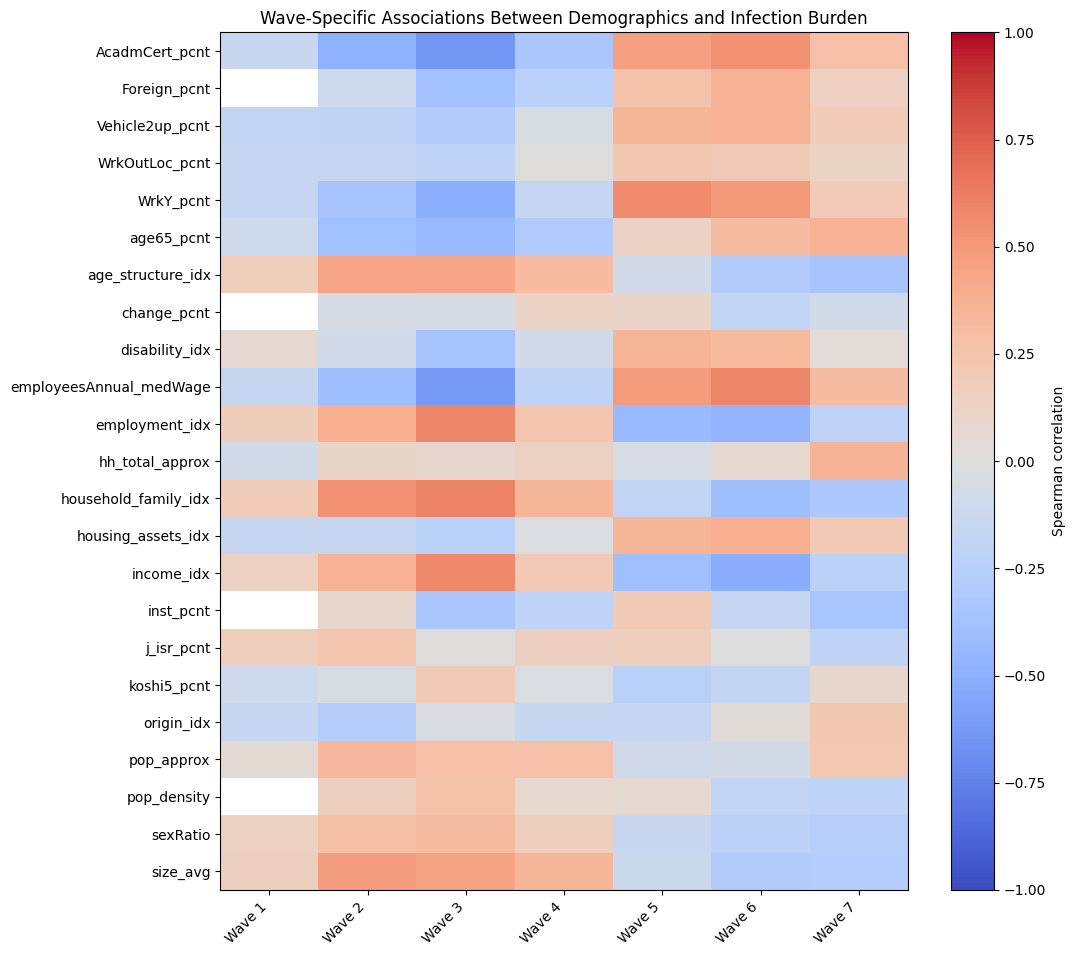

In [16]:
# ============================================================
# EDA: Wave-specific demographic associations
#
# Question:
# Do socio-demographic characteristics have stable associations
# with local infection burden across different COVID waves?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

wave_df = df_merged.reset_index().copy()

wave_df["date"] = pd.to_datetime(
    wave_df["date"],
    errors="coerce"
)

wave_df["infection_rate"] = pd.to_numeric(
    wave_df["infection_rate"],
    errors="coerce"
)

# Use statistical areas only.
# Do NOT mix city aggregate (_0) rows with their constituent areas.
wave_df = wave_df[
    wave_df["is_city_aggregate"] == 0
].copy()

# Keep census-matched rows
if "has_census" in wave_df.columns:
    wave_df = wave_df[
        wave_df["has_census"] == 1
    ].copy()

# Remove impossible infection-rate values
wave_df.loc[
    (wave_df["infection_rate"] < 0)
    | (wave_df["infection_rate"] > 1),
    "infection_rate"
] = np.nan


# ------------------------------------------------------------
# OPERATIONAL WAVE WINDOWS
# Adjust later if you choose different definitions
# ------------------------------------------------------------

WAVES = {
    "Wave 1": ("2020-03-01", "2020-05-31"),
    "Wave 2": ("2020-06-01", "2020-11-30"),
    "Wave 3": ("2020-12-01", "2021-05-31"),
    "Wave 4": ("2021-06-01", "2021-11-30"),
    "Wave 5": ("2021-12-01", "2022-03-31"),
    "Wave 6": ("2022-04-01", "2022-08-31"),
    "Wave 7": ("2022-09-01", "2023-05-31"),
}


def assign_wave(date):

    for wave_name, (start, end) in WAVES.items():

        if (
            pd.Timestamp(start)
            <= date
            <= pd.Timestamp(end)
        ):
            return wave_name

    return np.nan


wave_df["wave"] = wave_df["date"].apply(
    assign_wave
)

wave_df = wave_df.dropna(
    subset=["wave"]
)


# ------------------------------------------------------------
# DEMOGRAPHIC FEATURES
#
# Only continuous / ordered numeric variables here.
# Categorical codes such as Religion_Stat_Code should NOT
# be treated as continuous correlations.
# ------------------------------------------------------------

DEMOGRAPHIC_FEATURES = [
    "pop_approx",
    "hh_total_approx",
    "pop_density",
    "sexRatio",
    "inst_pcnt",
    "Foreign_pcnt",
    "change_pcnt",
    "WrkOutLoc_pcnt",
    "AcadmCert_pcnt",
    "age65_pcnt",
    "j_isr_pcnt",
    "size_avg",
    "WrkY_pcnt",
    "employeesAnnual_medWage",
    "Vehicle2up_pcnt",
    "koshi5_pcnt",

    # Composite census indices
    "age_structure_idx",
    "origin_idx",
    "household_family_idx",
    "employment_idx",
    "income_idx",
    "housing_assets_idx",
    "disability_idx",
]

# Keep only columns actually present
DEMOGRAPHIC_FEATURES = [
    col
    for col in DEMOGRAPHIC_FEATURES
    if col in wave_df.columns
]

# Force numeric
for col in DEMOGRAPHIC_FEATURES:

    wave_df[col] = pd.to_numeric(
        wave_df[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# CREATE ONE ROW PER AREA × WAVE
# ------------------------------------------------------------

# Static census information:
# one value per area
area_demographics = (
    wave_df
    .groupby("City_agas_code")[DEMOGRAPHIC_FEATURES]
    .first()
    .reset_index()
)


# Epidemiological burden within each wave
area_wave_burden = (
    wave_df
    .groupby(
        ["City_agas_code", "wave"],
        observed=True
    )
    .agg(

        # Typical infection rate during wave
        median_infection_rate=(
            "infection_rate",
            "median"
        ),

        # Average burden
        mean_infection_rate=(
            "infection_rate",
            "mean"
        ),

        # Robust "peak" instead of raw maximum
        p95_infection_rate=(
            "infection_rate",
            lambda x: x.quantile(0.95)
        ),

        n_days=(
            "infection_rate",
            "count"
        ),
    )
    .reset_index()
)


area_wave = area_wave_burden.merge(
    area_demographics,
    on="City_agas_code",
    how="left"
)


# ------------------------------------------------------------
# SELECT OUTCOME FOR CORRELATION
# ------------------------------------------------------------

BURDEN_METRIC = "median_infection_rate"

MIN_AREAS = 30


# ------------------------------------------------------------
# SPEARMAN CORRELATION:
# demographic feature vs burden, separately by wave
# ------------------------------------------------------------

corr_results = []

for wave_name in WAVES.keys():

    d = area_wave[
        area_wave["wave"] == wave_name
    ]

    for feature in DEMOGRAPHIC_FEATURES:

        pair = d[
            [feature, BURDEN_METRIC]
        ].dropna()

        if (
            len(pair) >= MIN_AREAS
            and pair[feature].nunique() > 1
            and pair[BURDEN_METRIC].nunique() > 1
        ):

            rho = pair.corr(
                method="spearman"
            ).iloc[0, 1]

        else:
            rho = np.nan

        corr_results.append({
            "wave": wave_name,
            "feature": feature,
            "rho": rho,
            "n_areas": len(pair)
        })


wave_demographic_corr = pd.DataFrame(
    corr_results
)


# ------------------------------------------------------------
# CORRELATION MATRIX
# ------------------------------------------------------------

corr_matrix = (
    wave_demographic_corr
    .pivot(
        index="feature",
        columns="wave",
        values="rho"
    )
    .reindex(columns=WAVES.keys())
)


print(
    corr_matrix.round(3)
)


# ------------------------------------------------------------
# HEATMAP
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, max(6, len(corr_matrix) * 0.42))
)

im = ax.imshow(
    corr_matrix.values,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    np.arange(len(corr_matrix.columns))
)

ax.set_xticklabels(
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    np.arange(len(corr_matrix.index))
)

ax.set_yticklabels(
    corr_matrix.index
)

ax.set_title(
    "Wave-Specific Associations Between Demographics and Infection Burden"
)

cbar = plt.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Spearman correlation"
)

plt.tight_layout()
plt.show()

## 2.7 · Vaccination — QC and coverage
QC first (any coverage > 100 % is a denominator bug, not a finding), then per-city curves and wave-start coverage vs subsequent burden.

VACCINATION QC
--------------
                         variable        n  missing_pct  median     p95  \
0   percent_vaccinated_first_dose  1403670        27.75   63.04  132.00   
1  percent_vaccinated_second_dose  1403670        27.75   57.27  123.19   
2   percent_vaccinated_third_dose  1403670        27.75   23.55   82.42   

      max  n_above_100  pct_above_100  n_below_0  
0  674.20       109429           5.63          0  
1  632.70        95551           4.92          0  
2  486.29        53306           2.74          0  


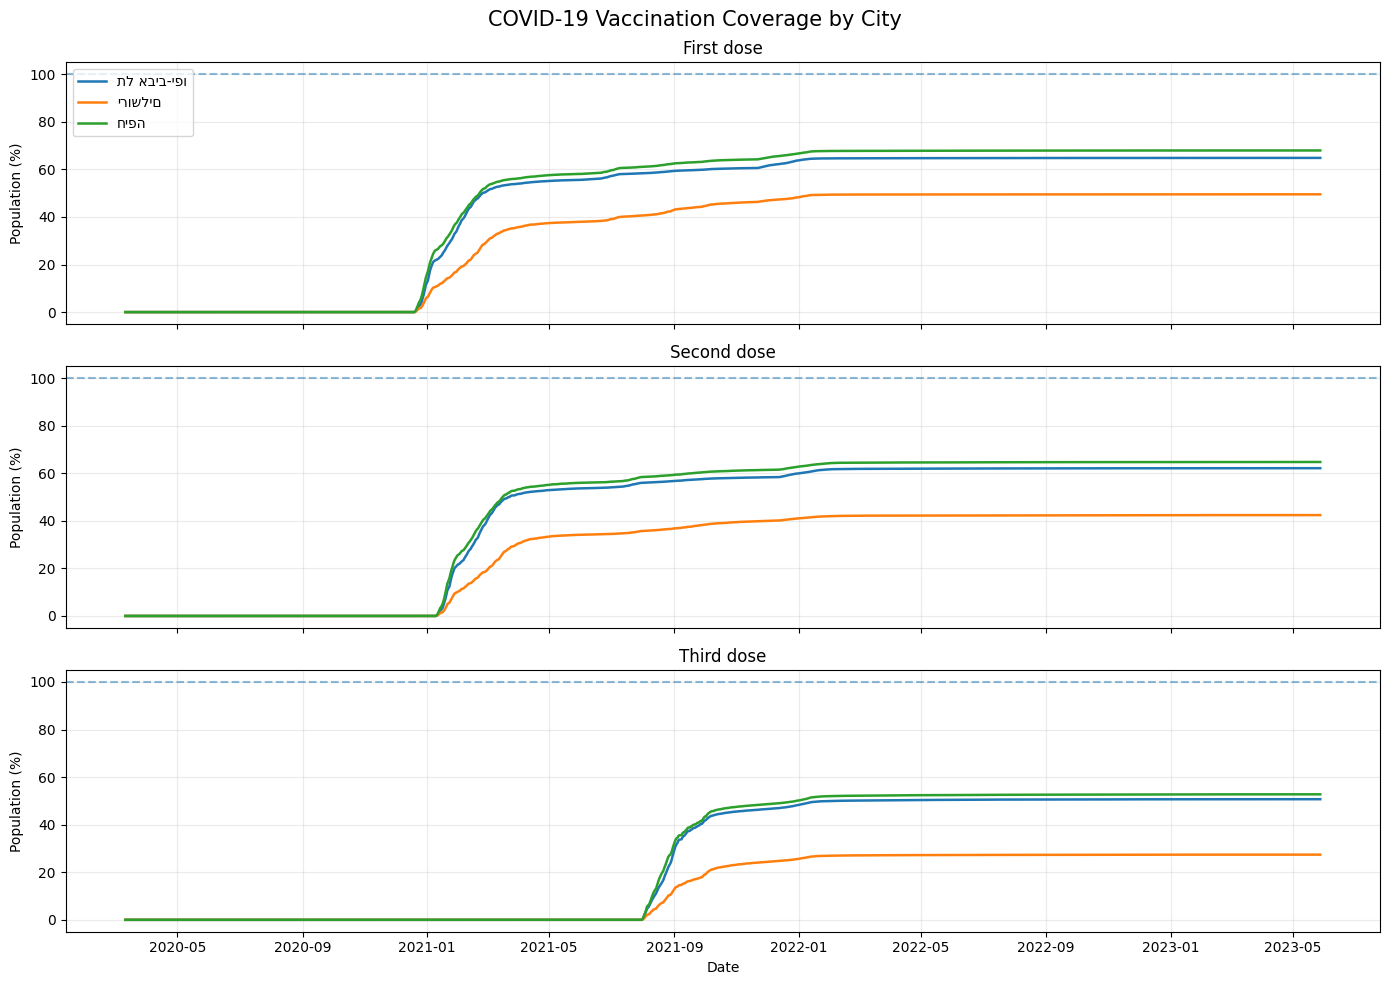


Vaccination at wave start vs wave infection burden:
wave         Wave 1  Wave 2  Wave 3  Wave 4  Wave 5  Wave 6  Wave 7
dose                                                               
First dose      NaN     NaN     NaN  -0.174   0.250   0.425   0.350
Second dose     NaN     NaN     NaN  -0.194   0.292   0.494   0.395
Third dose      NaN     NaN     NaN     NaN   0.394   0.564   0.429


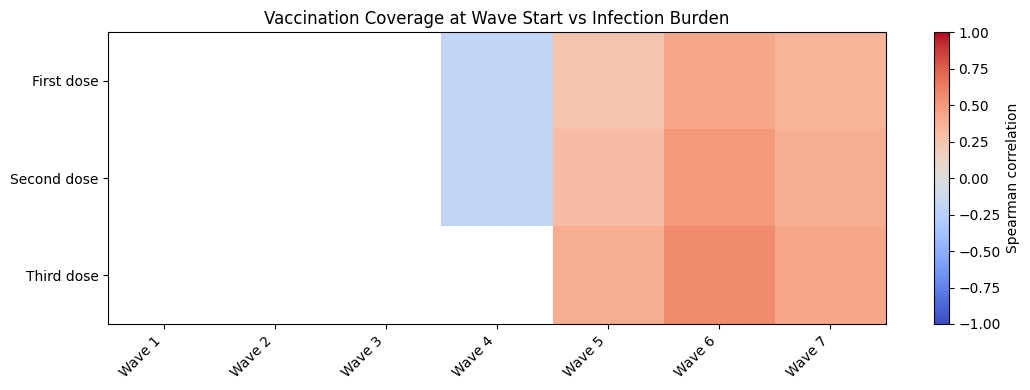

In [17]:
# ============================================================
# EDA: Vaccination coverage
# 1. QC
# 2. City-level trends
# 3. Wave-start vaccination vs infection burden
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# PREPARE
# ------------------------------------------------------------

vac_df = df_merged.reset_index().copy()

vac_df["date"] = pd.to_datetime(
    vac_df["date"],
    errors="coerce"
)

VAC_COLS = [
    "percent_vaccinated_first_dose",
    "percent_vaccinated_second_dose",
    "percent_vaccinated_third_dose",
]

for col in VAC_COLS:

    vac_df[col] = pd.to_numeric(
        vac_df[col],
        errors="coerce"
    )


# ============================================================
# PART A: VACCINATION QC
# ============================================================

qc_results = []

for col in VAC_COLS:

    x = vac_df[col]

    qc_results.append({

        "variable": col,

        "n": x.notna().sum(),

        "missing_pct":
            x.isna().mean() * 100,

        "median":
            x.median(),

        "p95":
            x.quantile(0.95),

        "max":
            x.max(),

        "n_above_100":
            (x > 100).sum(),

        "pct_above_100":
            (x > 100).mean() * 100,

        "n_below_0":
            (x < 0).sum(),
    })


vaccination_qc = pd.DataFrame(
    qc_results
)

print("VACCINATION QC")
print("--------------")

print(
    vaccination_qc.round(2)
)


# ============================================================
# PART B: CITY-LEVEL VACCINATION TRAJECTORIES
#
# Use aggregate city rows only.
# ============================================================

SELECTED_CITIES = [
    "תל אביב-יפו",
    "ירושלים",
    "חיפה"
]

city_vac = vac_df[
    (vac_df["is_city_aggregate"] == 1)
    & (vac_df["town"].isin(SELECTED_CITIES))
].copy()


dose_names = {
    "percent_vaccinated_first_dose":
        "First dose",

    "percent_vaccinated_second_dose":
        "Second dose",

    "percent_vaccinated_third_dose":
        "Third dose",
}


fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    sharex=True
)


for ax, col in zip(
    axes,
    VAC_COLS
):

    for city in SELECTED_CITIES:

        d = city_vac[
            city_vac["town"] == city
        ].sort_values("date")

        if d.empty:
            continue

        ax.plot(
            d["date"],
            d[col],
            linewidth=1.8,
            label=city
        )

    ax.axhline(
        100,
        linestyle="--",
        alpha=0.5
    )

    ax.set_ylabel(
        "Population (%)"
    )

    ax.set_title(
        dose_names[col]
    )

    ax.grid(
        alpha=0.25
    )


axes[0].legend(
    loc="upper left"
)

axes[-1].set_xlabel(
    "Date"
)

fig.suptitle(
    "COVID-19 Vaccination Coverage by City",
    fontsize=15
)

plt.tight_layout()
plt.show()


# ============================================================
# PART C:
# VACCINATION AT WAVE START
# vs INFECTION BURDEN DURING THAT WAVE
# ============================================================

# Statistical areas only
vac_area = vac_df[
    vac_df["is_city_aggregate"] == 0
].copy()

if "has_census" in vac_area.columns:

    vac_area = vac_area[
        vac_area["has_census"] == 1
    ].copy()


vac_area["infection_rate"] = pd.to_numeric(
    vac_area["infection_rate"],
    errors="coerce"
)

vac_area.loc[
    (vac_area["infection_rate"] < 0)
    | (vac_area["infection_rate"] > 1),
    "infection_rate"
] = np.nan


# Same wave definitions used above
WAVES = {
    "Wave 1": ("2020-03-01", "2020-05-31"),
    "Wave 2": ("2020-06-01", "2020-11-30"),
    "Wave 3": ("2020-12-01", "2021-05-31"),
    "Wave 4": ("2021-06-01", "2021-11-30"),
    "Wave 5": ("2021-12-01", "2022-03-31"),
    "Wave 6": ("2022-04-01", "2022-08-31"),
    "Wave 7": ("2022-09-01", "2023-05-31"),
}


vaccination_wave_results = []


for wave_name, (start, end) in WAVES.items():

    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    d = vac_area[
        (vac_area["date"] >= start)
        & (vac_area["date"] <= end)
    ].copy()

    if d.empty:
        continue


    # --------------------------------------------------------
    # Infection burden during whole wave
    # --------------------------------------------------------

    burden = (
        d
        .groupby("City_agas_code")
        ["infection_rate"]
        .median()
        .rename("wave_infection_burden")
    )


    # --------------------------------------------------------
    # Vaccination near beginning of wave
    #
    # Median during first 14 days makes this less sensitive
    # to one missing date.
    # --------------------------------------------------------

    start_window = d[
        d["date"]
        <= start + pd.Timedelta(days=13)
    ]

    coverage_start = (
        start_window
        .groupby("City_agas_code")[VAC_COLS]
        .median()
    )


    area_wave_vac = (
        coverage_start
        .join(burden)
        .reset_index()
    )


    for dose in VAC_COLS:

        pair = area_wave_vac[
            [
                dose,
                "wave_infection_burden"
            ]
        ].dropna()

        if (
            len(pair) >= 30
            and pair[dose].nunique() > 1
        ):

            rho = pair.corr(
                method="spearman"
            ).iloc[0, 1]

        else:
            rho = np.nan

        vaccination_wave_results.append({
            "wave": wave_name,
            "dose": dose_names[dose],
            "rho": rho,
            "n_areas": len(pair)
        })


vac_wave_corr = pd.DataFrame(
    vaccination_wave_results
)


vac_corr_matrix = (
    vac_wave_corr
    .pivot(
        index="dose",
        columns="wave",
        values="rho"
    )
    .reindex(columns=WAVES.keys())
)


print("\nVaccination at wave start vs wave infection burden:")
print(
    vac_corr_matrix.round(3)
)


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 4)
)

im = ax.imshow(
    vac_corr_matrix.values,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    np.arange(len(vac_corr_matrix.columns))
)

ax.set_xticklabels(
    vac_corr_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    np.arange(len(vac_corr_matrix.index))
)

ax.set_yticklabels(
    vac_corr_matrix.index
)

ax.set_title(
    "Vaccination Coverage at Wave Start vs Infection Burden"
)

cbar = plt.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Spearman correlation"
)

plt.tight_layout()
plt.show()

## 2.8 · Day-of-week reporting effects

  day_of_week  infection_rate_median  infection_rate_q25  infection_rate_q75  \
0      Monday                 0.0263              0.0059              0.0323   
1     Tuesday                 0.0256              0.0000              0.0312   
2   Wednesday                 0.0242              0.0000              0.0312   
3    Thursday                 0.0241              0.0000              0.0308   
4      Friday                 0.0244              0.0000              0.0312   
5    Saturday                 0.0251              0.0000              0.0318   
6      Sunday                 0.0258              0.0000              0.0312   

   panic_index_median  panic_index_q25  panic_index_q75  
0              3.4028           2.6461           4.2219  
1              3.3333           2.5402           4.0762  
2              3.2061           2.4676           4.0531  
3              2.9693           2.2901           3.6862  
4              2.7397           2.1424           3.3333  
5          

/tmp/ipykernel_1318260/2768496414.py:182: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


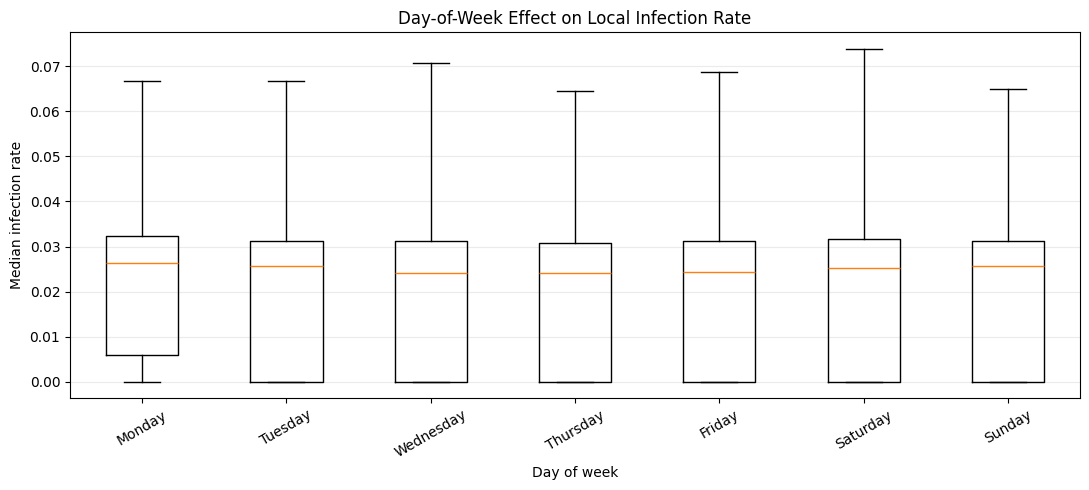

/tmp/ipykernel_1318260/2768496414.py:231: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


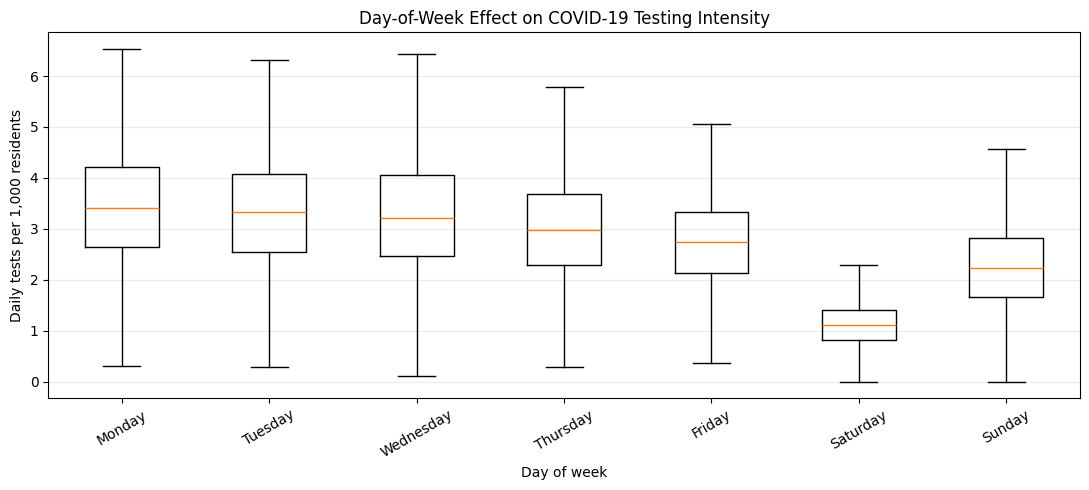

In [18]:
# ============================================================
# EDA: Day-of-week effects
#
# Are infection rate and testing intensity influenced by
# weekly testing/reporting patterns?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

dow_df = df_merged.reset_index().copy()

dow_df["date"] = pd.to_datetime(
    dow_df["date"],
    errors="coerce"
)

dow_df["infection_rate"] = pd.to_numeric(
    dow_df["infection_rate"],
    errors="coerce"
)

dow_df["panic_index"] = pd.to_numeric(
    dow_df["panic_index"],
    errors="coerce"
)


# Statistical areas only
dow_df = dow_df[
    dow_df["is_city_aggregate"] == 0
].copy()


# Clean impossible values
dow_df.loc[
    (dow_df["infection_rate"] < 0)
    | (dow_df["infection_rate"] > 1),
    "infection_rate"
] = np.nan

dow_df.loc[
    dow_df["panic_index"] < 0,
    "panic_index"
] = np.nan


# ------------------------------------------------------------
# CREATE WEEKDAY VARIABLE
# Monday = 0 ... Sunday = 6
# ------------------------------------------------------------

DAY_ORDER = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]


dow_df["day_of_week"] = (
    dow_df["date"]
    .dt.day_name()
)

dow_df["day_of_week"] = pd.Categorical(
    dow_df["day_of_week"],
    categories=DAY_ORDER,
    ordered=True
)


# ------------------------------------------------------------
# FIRST SUMMARIZE WITHIN EACH STATISTICAL AREA
#
# This avoids treating every daily row as independent.
# ------------------------------------------------------------

area_dow = (
    dow_df
    .groupby(
        [
            "City_agas_code",
            "day_of_week"
        ],
        observed=True
    )
    .agg(

        median_infection_rate=(
            "infection_rate",
            "median"
        ),

        median_panic_index=(
            "panic_index",
            "median"
        ),
    )
    .reset_index()
)


# ------------------------------------------------------------
# PRINT NATIONAL WEEKDAY SUMMARY
# ------------------------------------------------------------

weekday_summary = (
    area_dow
    .groupby(
        "day_of_week",
        observed=True
    )
    .agg(

        infection_rate_median=(
            "median_infection_rate",
            "median"
        ),

        infection_rate_q25=(
            "median_infection_rate",
            lambda x: x.quantile(0.25)
        ),

        infection_rate_q75=(
            "median_infection_rate",
            lambda x: x.quantile(0.75)
        ),

        panic_index_median=(
            "median_panic_index",
            "median"
        ),

        panic_index_q25=(
            "median_panic_index",
            lambda x: x.quantile(0.25)
        ),

        panic_index_q75=(
            "median_panic_index",
            lambda x: x.quantile(0.75)
        ),
    )
    .reset_index()
)


print(
    weekday_summary.round(4)
)


# ============================================================
# PLOT 1: INFECTION RATE BY WEEKDAY
# ============================================================

infection_data = [
    area_dow.loc[
        area_dow["day_of_week"] == day,
        "median_infection_rate"
    ].dropna().values

    for day in DAY_ORDER
]


fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.boxplot(
    infection_data,
    labels=DAY_ORDER,
    showfliers=False
)

ax.set_xlabel(
    "Day of week"
)

ax.set_ylabel(
    "Median infection rate"
)

ax.set_title(
    "Day-of-Week Effect on Local Infection Rate"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2: TESTING INTENSITY BY WEEKDAY
# ============================================================

panic_data = [
    area_dow.loc[
        area_dow["day_of_week"] == day,
        "median_panic_index"
    ].dropna().values

    for day in DAY_ORDER
]


fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.boxplot(
    panic_data,
    labels=DAY_ORDER,
    showfliers=False
)

ax.set_xlabel(
    "Day of week"
)

ax.set_ylabel(
    "Daily tests per 1,000 residents"
)

ax.set_title(
    "Day-of-Week Effect on COVID-19 Testing Intensity"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()

## EDA takeaways → modelling choices

1. Model at **statistical-area** level, not national.
2. Target = **daily local `infection_rate`**; include **testing volume** as a feature.
3. **Recent-history features** (lag, rolling mean) are expected to dominate.
4. Every model is compared against the **persistence baseline** and uses a
   **chronological** split (train strictly before test).
5. Static census structure is a *candidate* predictor at best — associations are
   unstable across waves (2.6).